<a href="https://colab.research.google.com/github/Nazarsiska735/Artificial-/blob/main/assignment3_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 3

1) Полносвязная нейронная сеть ( Fully-Connected Neural Network)

2) Нормализация по мини-батчам (Batch normalization)

3) Dropout

4) Сверточные нейронные сети (Convolutional Networks)

In [1]:
# Клонируем репозиторий и переходим в папку
!git clone https://github.com/JustHawker/AIT_Course_SamU_2026.git 2>/dev/null || echo "Already cloned"
%cd /content/AIT_Course_SamU_2026/lab_3
import sys
sys.path.insert(0, '/content/AIT_Course_SamU_2026/lab_3')
print("Готово ✓")


/content/AIT_Course_SamU_2026/lab_3
Готово ✓


Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory или на локальном компьютере.

In [2]:
%%writefile scripts/layers.py
import numpy as np


def affine_forward(x, w, b):
    out = x.reshape(x.shape[0], -1).dot(w) + b
    cache = (x, w, b)
    return out, cache


def affine_backward(dout, cache):
    x, w, b = cache
    x_flat = x.reshape(x.shape[0], -1)
    dx = dout.dot(w.T).reshape(x.shape)
    dw = x_flat.T.dot(dout)
    db = dout.sum(axis=0)
    return dx, dw, db


def relu_forward(x):
    out = np.maximum(0, x)
    cache = x
    return out, cache


def relu_backward(dout, cache):
    x = cache
    dx = dout * (x > 0)
    return dx


def batchnorm_forward(x, gamma, beta, bn_param):
    mode = bn_param['mode']
    eps = bn_param.get('eps', 1e-5)
    momentum = bn_param.get('momentum', 0.9)
    N, D = x.shape
    running_mean = bn_param.get('running_mean', np.zeros(D, dtype=x.dtype))
    running_var  = bn_param.get('running_var',  np.ones(D,  dtype=x.dtype))

    if mode == 'train':
        mu    = x.mean(axis=0)
        var   = x.var(axis=0)
        x_hat = (x - mu) / np.sqrt(var + eps)
        out   = gamma * x_hat + beta
        bn_param['running_mean'] = momentum * running_mean + (1 - momentum) * mu
        bn_param['running_var']  = momentum * running_var  + (1 - momentum) * var
        cache = (x, x_hat, mu, var, gamma, beta, eps)
    elif mode == 'test':
        x_hat = (x - running_mean) / np.sqrt(running_var + eps)
        out   = gamma * x_hat + beta
        cache = None
    else:
        raise ValueError('Invalid forward batchnorm mode "%s"' % mode)
    return out, cache


def batchnorm_backward(dout, cache):
    x, x_hat, mu, var, gamma, beta, eps = cache
    N, D = dout.shape
    dgamma = (dout * x_hat).sum(axis=0)
    dbeta  = dout.sum(axis=0)
    dx_hat = dout * gamma
    dvar   = (dx_hat * (x - mu) * (-0.5) * (var + eps)**(-1.5)).sum(axis=0)
    dmu    = (dx_hat * (-1.0 / np.sqrt(var + eps))).sum(axis=0) + dvar * (-2.0 * (x - mu)).mean(axis=0)
    dx     = dx_hat / np.sqrt(var + eps) + dvar * 2.0 * (x - mu) / N + dmu / N
    return dx, dgamma, dbeta


def layernorm_forward(x, gamma, beta, ln_param):
    eps = ln_param.get('eps', 1e-5)
    mu    = x.mean(axis=1, keepdims=True)
    var   = x.var(axis=1,  keepdims=True)
    x_hat = (x - mu) / np.sqrt(var + eps)
    out   = gamma * x_hat + beta
    cache = (x, x_hat, mu, var, gamma, beta, eps)
    return out, cache


def layernorm_backward(dout, cache):
    x, x_hat, mu, var, gamma, beta, eps = cache
    N, D = dout.shape
    dgamma = (dout * x_hat).sum(axis=0)
    dbeta  = dout.sum(axis=0)
    dx_hat = dout * gamma
    dvar   = (dx_hat * (x - mu) * (-0.5) * (var + eps)**(-1.5)).sum(axis=1, keepdims=True)
    dmu    = (dx_hat / (-np.sqrt(var + eps))).sum(axis=1, keepdims=True) + dvar * (-2.0*(x-mu)).mean(axis=1, keepdims=True)
    dx     = dx_hat / np.sqrt(var + eps) + dvar * 2.0*(x-mu)/D + dmu/D
    return dx, dgamma, dbeta


def dropout_forward(x, dropout_param):
    p    = dropout_param['p']
    mode = dropout_param['mode']
    if 'seed' in dropout_param:
        np.random.seed(dropout_param['seed'])
    if mode == 'train':
        mask = (np.random.rand(*x.shape) > p) / (1.0 - p)
        out  = x * mask
    else:
        out  = x
        mask = None
    cache = (dropout_param, mask)
    return out, cache


def dropout_backward(dout, cache):
    dropout_param, mask = cache
    mode = dropout_param['mode']
    if mode == 'train':
        dx = dout * mask
    else:
        dx = dout
    return dx


def conv_forward_naive(x, w, b, conv_param):
    N, C, H, W_   = x.shape
    F, _, HH, WW  = w.shape
    stride = conv_param['stride']
    pad    = conv_param['pad']
    H_out  = 1 + (H + 2*pad - HH) // stride
    W_out  = 1 + (W_ + 2*pad - WW) // stride
    x_pad  = np.pad(x, ((0,),(0,),(pad,),(pad,)), mode='constant')
    out    = np.zeros((N, F, H_out, W_out))
    for n in range(N):
        for f in range(F):
            for i in range(H_out):
                for j in range(W_out):
                    h0, w0 = i*stride, j*stride
                    out[n,f,i,j] = np.sum(x_pad[n,:,h0:h0+HH,w0:w0+WW] * w[f]) + b[f]
    cache = (x, w, b, conv_param)
    return out, cache


def conv_backward_naive(dout, cache):
    x, w, b, conv_param = cache
    N, C, H, W_   = x.shape
    F, _, HH, WW  = w.shape
    stride = conv_param['stride']
    pad    = conv_param['pad']
    H_out, W_out  = dout.shape[2], dout.shape[3]
    x_pad  = np.pad(x, ((0,),(0,),(pad,),(pad,)), mode='constant')
    dx_pad = np.zeros_like(x_pad)
    dw     = np.zeros_like(w)
    db     = np.zeros_like(b)
    for n in range(N):
        for f in range(F):
            db[f] += dout[n,f].sum()
            for i in range(H_out):
                for j in range(W_out):
                    h0, w0 = i*stride, j*stride
                    dw[f]          += x_pad[n,:,h0:h0+HH,w0:w0+WW] * dout[n,f,i,j]
                    dx_pad[n,:,h0:h0+HH,w0:w0+WW] += w[f] * dout[n,f,i,j]
    dx = dx_pad[:,:,pad:-pad,pad:-pad] if pad > 0 else dx_pad
    return dx, dw, db


def max_pool_forward_naive(x, pool_param):
    N, C, H, W_ = x.shape
    ph = pool_param['pool_height']
    pw = pool_param['pool_width']
    s  = pool_param['stride']
    H_out = (H - ph) // s + 1
    W_out = (W_ - pw) // s + 1
    out   = np.zeros((N, C, H_out, W_out))
    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    out[n,c,i,j] = x[n,c,i*s:i*s+ph, j*s:j*s+pw].max()
    cache = (x, pool_param)
    return out, cache


def max_pool_backward_naive(dout, cache):
    x, pool_param = cache
    N, C, H, W_ = x.shape
    ph = pool_param['pool_height']
    pw = pool_param['pool_width']
    s  = pool_param['stride']
    H_out, W_out = dout.shape[2], dout.shape[3]
    dx = np.zeros_like(x)
    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    patch = x[n,c,i*s:i*s+ph, j*s:j*s+pw]
                    mask  = (patch == patch.max())
                    dx[n,c,i*s:i*s+ph, j*s:j*s+pw] += mask * dout[n,c,i,j]
    return dx


def spatial_batchnorm_forward(x, gamma, beta, bn_param):
    N, C, H, W = x.shape
    x_reshaped = x.transpose(0,2,3,1).reshape(-1, C)
    out_flat, cache = batchnorm_forward(x_reshaped, gamma, beta, bn_param)
    out = out_flat.reshape(N, H, W, C).transpose(0,3,1,2)
    return out, cache


def spatial_batchnorm_backward(dout, cache):
    N, C, H, W = dout.shape
    dout_flat = dout.transpose(0,2,3,1).reshape(-1, C)
    dx_flat, dgamma, dbeta = batchnorm_backward(dout_flat, cache)
    dx = dx_flat.reshape(N, H, W, C).transpose(0,3,1,2)
    return dx, dgamma, dbeta


def svm_loss(x, y):
    N = x.shape[0]
    correct = x[np.arange(N), y]
    margins = np.maximum(0, x - correct[:,None] + 1.0)
    margins[np.arange(N), y] = 0
    loss = margins.sum() / N
    dx   = (margins > 0).astype(float)
    dx[np.arange(N), y] -= dx.sum(axis=1)
    dx /= N
    return loss, dx


def softmax_loss(x, y):
    N = x.shape[0]
    x_shifted = x - x.max(axis=1, keepdims=True)
    probs = np.exp(x_shifted) / np.exp(x_shifted).sum(axis=1, keepdims=True)
    loss  = -np.log(probs[np.arange(N), y] + 1e-15).mean()
    dx    = probs.copy()
    dx[np.arange(N), y] -= 1
    dx /= N
    return loss, dx


Overwriting scripts/layers.py


In [3]:
%%writefile scripts/layer_utils.py
from scripts.layers import *


def affine_relu_forward(x, w, b):
    a, fc_cache    = affine_forward(x, w, b)
    out, relu_cache = relu_forward(a)
    cache = (fc_cache, relu_cache)
    return out, cache


def affine_relu_backward(dout, cache):
    fc_cache, relu_cache = cache
    da         = relu_backward(dout, relu_cache)
    dx, dw, db = affine_backward(da, fc_cache)
    return dx, dw, db


def affine_bn_relu_forward(x, w, b, gamma, beta, bn_param):
    a, fc_cache    = affine_forward(x, w, b)
    bn, bn_cache   = batchnorm_forward(a, gamma, beta, bn_param)
    out, relu_cache = relu_forward(bn)
    cache = (fc_cache, bn_cache, relu_cache)
    return out, cache


def affine_bn_relu_backward(dout, cache):
    fc_cache, bn_cache, relu_cache = cache
    dbn             = relu_backward(dout, relu_cache)
    da, dgamma, dbeta = batchnorm_backward(dbn, bn_cache)
    dx, dw, db      = affine_backward(da, fc_cache)
    return dx, dw, db, dgamma, dbeta


def affine_ln_relu_forward(x, w, b, gamma, beta, ln_param):
    a, fc_cache    = affine_forward(x, w, b)
    ln, ln_cache   = layernorm_forward(a, gamma, beta, ln_param)
    out, relu_cache = relu_forward(ln)
    cache = (fc_cache, ln_cache, relu_cache)
    return out, cache


def affine_ln_relu_backward(dout, cache):
    fc_cache, ln_cache, relu_cache = cache
    dln             = relu_backward(dout, relu_cache)
    da, dgamma, dbeta = layernorm_backward(dln, ln_cache)
    dx, dw, db      = affine_backward(da, fc_cache)
    return dx, dw, db, dgamma, dbeta


def conv_relu_forward(x, w, b, conv_param):
    a, conv_cache   = conv_forward_naive(x, w, b, conv_param)
    out, relu_cache = relu_forward(a)
    cache = (conv_cache, relu_cache)
    return out, cache


def conv_relu_backward(dout, cache):
    conv_cache, relu_cache = cache
    da         = relu_backward(dout, relu_cache)
    dx, dw, db = conv_backward_naive(da, conv_cache)
    return dx, dw, db


def conv_relu_pool_forward(x, w, b, conv_param, pool_param):
    a, conv_cache   = conv_forward_naive(x, w, b, conv_param)
    s, relu_cache   = relu_forward(a)
    out, pool_cache = max_pool_forward_naive(s, pool_param)
    cache = (conv_cache, relu_cache, pool_cache)
    return out, cache


def conv_relu_pool_backward(dout, cache):
    conv_cache, relu_cache, pool_cache = cache
    ds         = max_pool_backward_naive(dout, pool_cache)
    da         = relu_backward(ds, relu_cache)
    dx, dw, db = conv_backward_naive(da, conv_cache)
    return dx, dw, db


Overwriting scripts/layer_utils.py


In [4]:
%%writefile scripts/optim.py
import numpy as np


def sgd(w, dw, config=None):
    if config is None: config = {}
    config.setdefault('learning_rate', 1e-2)
    w -= config['learning_rate'] * dw
    return w, config


def sgd_momentum(w, dw, config=None):
    if config is None: config = {}
    config.setdefault('learning_rate', 1e-2)
    config.setdefault('momentum', 0.9)
    config.setdefault('velocity', np.zeros_like(w))
    v  = config['momentum'] * config['velocity'] - config['learning_rate'] * dw
    config['velocity'] = v
    next_w = w + v
    return next_w, config


def rmsprop(w, dw, config=None):
    if config is None: config = {}
    config.setdefault('learning_rate', 1e-2)
    config.setdefault('decay_rate', 0.99)
    config.setdefault('epsilon', 1e-8)
    config.setdefault('cache', np.zeros_like(w))
    config['cache'] = config['decay_rate']*config['cache'] + (1-config['decay_rate'])*(dw**2)
    next_w = w - config['learning_rate'] * dw / (np.sqrt(config['cache']) + config['epsilon'])
    return next_w, config


def adam(w, dw, config=None):
    if config is None: config = {}
    config.setdefault('learning_rate', 1e-3)
    config.setdefault('beta1', 0.9)
    config.setdefault('beta2', 0.999)
    config.setdefault('epsilon', 1e-8)
    config.setdefault('m', np.zeros_like(w))
    config.setdefault('v', np.zeros_like(w))
    config.setdefault('t', 0)
    config['t'] += 1
    config['m'] = config['beta1']*config['m'] + (1-config['beta1'])*dw
    config['v'] = config['beta2']*config['v'] + (1-config['beta2'])*(dw**2)
    m_hat = config['m'] / (1 - config['beta1']**config['t'])
    v_hat = config['v'] / (1 - config['beta2']**config['t'])
    next_w = w - config['learning_rate'] * m_hat / (np.sqrt(v_hat) + config['epsilon'])
    return next_w, config


Overwriting scripts/optim.py


In [5]:
%%writefile scripts/classifiers/fc_net.py
import numpy as np
from scripts.layers import *
from scripts.layer_utils import *


class TwoLayerNet(object):
    def __init__(self, input_dim=3*32*32, hidden_dim=100, num_classes=10,
                 weight_scale=1e-3, reg=0.0):
        self.params = {}
        self.reg    = reg
        self.params['W1'] = weight_scale * np.random.randn(input_dim, hidden_dim)
        self.params['b1'] = np.zeros(hidden_dim)
        self.params['W2'] = weight_scale * np.random.randn(hidden_dim, num_classes)
        self.params['b2'] = np.zeros(num_classes)

    def loss(self, X, y=None):
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']

        h, cache1    = affine_relu_forward(X, W1, b1)
        scores, cache2 = affine_forward(h, W2, b2)

        if y is None:
            return scores

        loss, dscores = softmax_loss(scores, y)
        loss += 0.5 * self.reg * (np.sum(W1**2) + np.sum(W2**2))

        dh,  dW2, db2 = affine_backward(dscores, cache2)
        dX,  dW1, db1 = affine_relu_backward(dh, cache1)
        dW2 += self.reg * W2
        dW1 += self.reg * W1

        grads = {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}
        return loss, grads


class FullyConnectedNet(object):
    def __init__(self, hidden_dims, input_dim=3*32*32, num_classes=10,
                 dropout=1, normalization=None, reg=0.0,
                 weight_scale=1e-2, dtype=np.float32, seed=None):
        self.normalization = normalization
        self.use_dropout   = dropout != 1
        self.reg           = reg
        self.num_layers    = 1 + len(hidden_dims)
        self.dtype         = dtype
        self.params        = {}

        dims = [input_dim] + list(hidden_dims) + [num_classes]
        for i in range(self.num_layers):
            self.params['W%d' % (i+1)] = weight_scale * np.random.randn(dims[i], dims[i+1])
            self.params['b%d' % (i+1)] = np.zeros(dims[i+1])
            if normalization in ('batchnorm', 'layernorm') and i < self.num_layers - 1:
                self.params['gamma%d' % (i+1)] = np.ones(dims[i+1])
                self.params['beta%d'  % (i+1)] = np.zeros(dims[i+1])

        self.dropout_param = {}
        if self.use_dropout:
            self.dropout_param = {'mode': 'train', 'p': dropout}
            if seed is not None:
                self.dropout_param['seed'] = seed

        self.bn_params = []
        if normalization == 'batchnorm':
            self.bn_params = [{'mode': 'train'} for _ in range(self.num_layers - 1)]
        if normalization == 'layernorm':
            self.bn_params = [{} for _ in range(self.num_layers - 1)]

        for k, v in self.params.items():
            self.params[k] = v.astype(dtype)

    def loss(self, X, y=None):
        X = X.astype(self.dtype)
        mode = 'test' if y is None else 'train'

        if self.use_dropout:
            self.dropout_param['mode'] = mode
        if self.normalization == 'batchnorm':
            for bp in self.bn_params:
                bp['mode'] = mode

        caches = []
        out = X

        for i in range(self.num_layers - 1):
            W = self.params['W%d' % (i+1)]
            b = self.params['b%d' % (i+1)]

            if self.normalization == 'batchnorm':
                gamma = self.params['gamma%d' % (i+1)]
                beta  = self.params['beta%d'  % (i+1)]
                out, cache = affine_bn_relu_forward(out, W, b, gamma, beta, self.bn_params[i])
            elif self.normalization == 'layernorm':
                gamma = self.params['gamma%d' % (i+1)]
                beta  = self.params['beta%d'  % (i+1)]
                out, cache = affine_ln_relu_forward(out, W, b, gamma, beta, self.bn_params[i])
            else:
                out, cache = affine_relu_forward(out, W, b)

            caches.append(cache)

            if self.use_dropout:
                out, dc = dropout_forward(out, self.dropout_param)
                caches.append(('dropout', dc))

        W = self.params['W%d' % self.num_layers]
        b = self.params['b%d' % self.num_layers]
        scores, cache = affine_forward(out, W, b)
        caches.append(cache)

        if y is None:
            return scores

        loss, dscores = softmax_loss(scores, y)
        for i in range(1, self.num_layers + 1):
            loss += 0.5 * self.reg * np.sum(self.params['W%d' % i]**2)

        grads = {}
        dx, dW, db = affine_backward(dscores, caches.pop())
        dW += self.reg * self.params['W%d' % self.num_layers]
        grads['W%d' % self.num_layers] = dW
        grads['b%d' % self.num_layers] = db

        for i in range(self.num_layers - 2, -1, -1):
            if self.use_dropout:
                _, dc = caches.pop()
                dx = dropout_backward(dx, dc)

            cache = caches.pop()

            if self.normalization == 'batchnorm':
                dx, dW, db, dgamma, dbeta = affine_bn_relu_backward(dx, cache)
                grads['gamma%d' % (i+1)] = dgamma
                grads['beta%d'  % (i+1)] = dbeta
            elif self.normalization == 'layernorm':
                dx, dW, db, dgamma, dbeta = affine_ln_relu_backward(dx, cache)
                grads['gamma%d' % (i+1)] = dgamma
                grads['beta%d'  % (i+1)] = dbeta
            else:
                dx, dW, db = affine_relu_backward(dx, cache)

            dW += self.reg * self.params['W%d' % (i+1)]
            grads['W%d' % (i+1)] = dW
            grads['b%d' % (i+1)] = db

        return loss, grads


Overwriting scripts/classifiers/fc_net.py


In [6]:
%%writefile scripts/classifiers/cnn.py
import numpy as np
from scripts.layers import *
from scripts.layer_utils import *


class ThreeLayerConvNet(object):
    """
    A three-layer convolutional network with the following architecture:
    conv - relu - 2x2 max pool - affine - relu - affine - softmax
    """
    def __init__(self, input_dim=(3, 32, 32), num_filters=32, filter_size=7,
                 hidden_dim=100, num_classes=10, weight_scale=1e-3, reg=0.0,
                 dtype=np.float32):
        self.params = {}
        self.reg    = reg
        self.dtype  = dtype

        C, H, W = input_dim
        self.params['W1'] = weight_scale * np.random.randn(num_filters, C, filter_size, filter_size)
        self.params['b1'] = np.zeros(num_filters)

        pool_h = H // 2
        pool_w = W // 2
        self.params['W2'] = weight_scale * np.random.randn(num_filters * pool_h * pool_w, hidden_dim)
        self.params['b2'] = np.zeros(hidden_dim)
        self.params['W3'] = weight_scale * np.random.randn(hidden_dim, num_classes)
        self.params['b3'] = np.zeros(num_classes)

        for k, v in self.params.items():
            self.params[k] = v.astype(dtype)

    def loss(self, X, y=None):
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']
        W3, b3 = self.params['W3'], self.params['b3']

        filter_size = W1.shape[2]
        conv_param  = {'stride': 1, 'pad': (filter_size - 1) // 2}
        pool_param  = {'pool_height': 2, 'pool_width': 2, 'stride': 2}

        out1, cache1 = conv_relu_pool_forward(X, W1, b1, conv_param, pool_param)
        out2, cache2 = affine_relu_forward(out1, W2, b2)
        scores, cache3 = affine_forward(out2, W3, b3)

        if y is None:
            return scores

        loss, dscores = softmax_loss(scores, y)
        loss += 0.5 * self.reg * (np.sum(W1**2) + np.sum(W2**2) + np.sum(W3**2))

        dout2, dW3, db3 = affine_backward(dscores, cache3)
        dout1, dW2, db2 = affine_relu_backward(dout2, cache2)
        dX,    dW1, db1 = conv_relu_pool_backward(dout1, cache1)

        dW1 += self.reg * W1
        dW2 += self.reg * W2
        dW3 += self.reg * W3

        grads = {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2, 'W3': dW3, 'b3': db3}
        return loss, grads


Overwriting scripts/classifiers/cnn.py


# Полносвязная нейронная сеть

В данной лабораторной работе необходимо будет реализовать полносвязную нейронную сеть, используя модульный подход.

In [7]:
from __future__ import print_function
import time
import numpy as np
import matplotlib.pyplot as plt
from scripts.classifiers.fc_net import *
from scripts.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from scripts.solver import Solver
from scripts.classifiers.cnn import *
from scripts.layers import *
from scripts.fast_layers import *

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

try:
    %load_ext autoreload
    %autoreload 2
except:
    pass

def rel_error(x, y):
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

def print_mean_std(x, axis=0):
    print('  means: ', x.mean(axis=axis))
    print('  stds:  ', x.std(axis=axis))
    print()

print("Импорт выполнен ✓")


=========== You can safely ignore the message below if you are NOT working on ConvolutionalNetworks.ipynb ===========
	You will need to compile a Cython extension for a portion of this assignment.
	The instructions to do this will be given in a section of the notebook below.
	There will be an option for Colab users and another for Jupyter (local) users.
Импорт выполнен ✓


Загрузите данные из предыдущей лабораторной работы.

In [8]:
import os, pickle, tarfile, urllib.request

cifar_url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
cifar_tar = 'cifar-10-python.tar.gz'
cifar_dir = 'cifar-10-batches-py'

if not os.path.exists(cifar_dir):
    if not os.path.exists(cifar_tar):
        urllib.request.urlretrieve(cifar_url, cifar_tar)
    with tarfile.open(cifar_tar, 'r:gz') as t:
        t.extractall('.')

def load_cifar_batch(f):
    with open(f, 'rb') as fp:
        d = pickle.load(fp, encoding='bytes')
    return d[b'data'].reshape(-1,3,32,32), np.array(d[b'labels'])

def load_CIFAR10(root):
    Xs, ys = [], []
    for i in range(1, 6):
        X, y = load_cifar_batch(os.path.join(root, 'data_batch_%d' % i))
        Xs.append(X); ys.append(y)
    Xtr = np.concatenate(Xs).astype(np.float32)
    ytr = np.concatenate(ys)
    Xte, yte = load_cifar_batch(os.path.join(root, 'test_batch'))
    return Xtr, ytr, Xte.astype(np.float32), yte

def get_CIFAR10_data(num_train=49000, num_val=1000, num_test=1000):
    Xtr, ytr, Xte, yte = load_CIFAR10(cifar_dir)
    # flatten
    X_train = Xtr[:num_train].reshape(num_train, -1)
    y_train = ytr[:num_train]
    X_val   = Xtr[num_train:num_train+num_val].reshape(num_val, -1)
    y_val   = ytr[num_train:num_train+num_val]
    X_test  = Xte[:num_test].reshape(num_test, -1)
    y_test  = yte[:num_test]
    mean = X_train.mean(axis=0)
    X_train -= mean; X_val -= mean; X_test -= mean
    # CNN format (N, C, H, W)
    X_train_cnn = Xtr[:num_train]
    X_val_cnn   = Xtr[num_train:num_train+num_val]
    X_test_cnn  = Xte[:num_test]
    mean_cnn = X_train_cnn.mean(axis=(0,2,3), keepdims=True)
    X_train_cnn -= mean_cnn; X_val_cnn -= mean_cnn; X_test_cnn -= mean_cnn
    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val':   X_val,   'y_val':   y_val,
        'X_test':  X_test,  'y_test':  y_test,
        'X_train_cnn': X_train_cnn,
        'X_val_cnn':   X_val_cnn,
        'X_test_cnn':  X_test_cnn,
    }

data = get_CIFAR10_data()
for k, v in data.items():
    print(k, v.shape)


/tmp/ipykernel_1156/3284271651.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall('.')


X_train (49000, 3072)
y_train (49000,)
X_val (1000, 3072)
y_val (1000,)
X_test (1000, 3072)
y_test (1000,)
X_train_cnn (49000, 3, 32, 32)
X_val_cnn (1000, 3, 32, 32)
X_test_cnn (1000, 3, 32, 32)


Для полносвязного слоя реализуйте прямой проход (метод affine_forward в scripts/layers.py). Протестируйте свою реализацию.

In [9]:
num_inputs = 2
input_shape = (4, 5, 6)
output_dim = 3

input_size = num_inputs * np.prod(input_shape)
weight_size = output_dim * np.prod(input_shape)

x = np.linspace(-0.1, 0.5, num=input_size).reshape(num_inputs, *input_shape)
w = np.linspace(-0.2, 0.3, num=weight_size).reshape(np.prod(input_shape), output_dim)
b = np.linspace(-0.3, 0.1, num=output_dim)

out, _ = affine_forward(x, w, b)
correct_out = np.array([[ 1.49834967,  1.70660132,  1.91485297],
                        [ 3.25553199,  3.5141327,   3.77273342]])

print('Testing affine_forward function:')
print('difference: ', rel_error(out, correct_out))


Testing affine_forward function:
difference:  9.769848888397517e-10


Для полносвязного слоя реализуйте обратный проход (метод affine_backward в scripts/layers.py). Протестируйте свою реализацию.

In [10]:
np.random.seed(231)
x = np.random.randn(10, 2, 3)
w = np.random.randn(6, 5)
b = np.random.randn(5)
dout = np.random.randn(10, 5)

dx_num = eval_numerical_gradient_array(lambda x: affine_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_forward(x, w, b)[0], b, dout)

_, cache = affine_forward(x, w, b)
dx, dw, db = affine_backward(dout, cache)

print('Testing affine_backward function:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))


Testing affine_backward function:
dx error:  5.399100368651805e-11
dw error:  9.904211865398145e-11
db error:  2.4122867568119087e-11


Реализуйте прямой проход для слоя активации ReLU (relu_forward) и протестируйте его.

In [11]:
x = np.linspace(-0.5, 0.5, num=12).reshape(3, 4)

out, _ = relu_forward(x)
correct_out = np.array([[ 0.,          0.,          0.,          0.,        ],
                        [ 0.,          0.,          0.04545455,  0.13636364,],
                        [ 0.22727273,  0.31818182,  0.40909091,  0.5,       ]])

print('Testing relu_forward function:')
print('difference: ', rel_error(out, correct_out))


Testing relu_forward function:
difference:  4.999999798022158e-08


Реализуйте обратный проход для слоя активации ReLU (relu_backward) и протестируйте его.

In [12]:
np.random.seed(231)
x = np.random.randn(10, 10)
dout = np.random.randn(*x.shape)

dx_num = eval_numerical_gradient_array(lambda x: relu_forward(x)[0], x, dout)

_, cache = relu_forward(x)
dx = relu_backward(dout, cache)

print('Testing relu_backward function:')
print('dx error: ', rel_error(dx_num, dx))


Testing relu_backward function:
dx error:  3.2756349136310288e-12


Ознакомьтесь с функциями affine_relu_forward и affine_relu_backward, запустите код ниже и убедитесь, что ошибка порядка e-10 или ниже.

In [13]:
from scripts.layer_utils import affine_relu_forward, affine_relu_backward
np.random.seed(231)
x = np.random.randn(2, 3, 4)
w = np.random.randn(12, 10)
b = np.random.randn(10)
dout = np.random.randn(2, 10)

out, cache = affine_relu_forward(x, w, b)
dx, dw, db = affine_relu_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: affine_relu_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_relu_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_relu_forward(x, w, b)[0], b, dout)

print('Testing affine_relu_forward and affine_relu_backward:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))


Testing affine_relu_forward and affine_relu_backward:
dx error:  2.299579177309368e-11
dw error:  8.162011105764925e-11
db error:  7.826724021458994e-12


Реализуйте двухслойную полносвязную сеть - класс TwoLayerNet в scripts/classifiers/fc_net.py. Проверьте свою реализацию, запустив код ниже.

In [14]:
np.random.seed(231)
N, D, H, C = 3, 5, 50, 7
X = np.random.randn(N, D)
y = np.random.randint(C, size=N)

std = 1e-3
model = TwoLayerNet(input_dim=D, hidden_dim=H, num_classes=C, weight_scale=std)

print('Testing initialization ... ')
W1_std = abs(model.params['W1'].std() - std)
b1 = model.params['b1']
W2_std = abs(model.params['W2'].std() - std)
b2 = model.params['b2']
assert W1_std < std / 10, 'First layer weights do not seem right'
assert np.all(b1 == 0), 'First layer biases do not seem right'
assert W2_std < std / 10, 'Second layer weights do not seem right'
assert np.all(b2 == 0), 'Second layer biases do not seem right'

print('Testing test-time forward pass ... ')
model.params['W1'] = np.linspace(-0.7, 0.3, num=D*H).reshape(D, H)
model.params['b1'] = np.linspace(-0.1, 0.9, num=H)
model.params['W2'] = np.linspace(-0.3, 0.4, num=H*C).reshape(H, C)
model.params['b2'] = np.linspace(-0.9, 0.1, num=C)
X = np.linspace(-5.5, 4.5, num=N*D).reshape(D, N).T
scores = model.loss(X)
correct_scores = np.asarray(
  [[11.53165108,  12.2917344,   13.05181771,  13.81190102,  14.57198434, 15.33206765,  16.09215096],
   [12.05769098,  12.74614105,  13.43459113,  14.1230412,   14.81149128, 15.49994135,  16.18839143],
   [12.58373087,  13.20054771,  13.81736455,  14.43418138,  15.05099822, 15.66781506,  16.2846319 ]])
scores_diff = np.abs(scores - correct_scores).sum()
assert scores_diff < 1e-6, 'Problem with test-time forward pass'

print('Testing training loss (no regularization)')
y = np.asarray([0, 5, 1])
loss, grads = model.loss(X, y)
correct_loss = 3.4702243556
assert abs(loss - correct_loss) < 1e-10, 'Problem with training-time loss'

model.reg = 1.0
loss, grads = model.loss(X, y)
correct_loss = 26.5948426952
assert abs(loss - correct_loss) < 1e-10, 'Problem with regularization loss'

for reg in [0.0, 0.7]:
    print('Running numeric gradient check with reg = ', reg)
    model.reg = reg
    loss, grads = model.loss(X, y)
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False)
        print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))


Testing initialization ... 
Testing test-time forward pass ... 
Testing training loss (no regularization)
Running numeric gradient check with reg =  0.0
W1 relative error: 1.52e-08
W2 relative error: 3.18e-10
b1 relative error: 6.55e-09
b2 relative error: 2.53e-10
Running numeric gradient check with reg =  0.7
W1 relative error: 2.53e-07
W2 relative error: 2.85e-08
b1 relative error: 1.35e-08
b2 relative error: 9.09e-10


Используйте экземпляр класса Solver для обучения двухслойной полносвязной сети. Необходимо достичь минимум 50% верно классифицированных объектов на валидационном наборе.

In [15]:
model = TwoLayerNet()
solver = Solver(model, data,
                update_rule='sgd_momentum',
                optim_config={'learning_rate': 5e-3, 'momentum': 0.9},
                lr_decay=0.95,
                num_epochs=10, batch_size=100,
                print_every=200, verbose=True)
solver.train()


(Iteration 1 / 4900) loss: 2.304060
(Epoch 0 / 10) train acc: 0.138000; val_acc: 0.144000
(Iteration 201 / 4900) loss: 32.811838
(Iteration 401 / 4900) loss: 31.430287
(Epoch 1 / 10) train acc: 0.123000; val_acc: 0.114000
(Iteration 601 / 4900) loss: 30.739511


/content/AIT_Course_SamU_2026/lab_3/scripts/layers.py:222: RuntimeWarning: overflow encountered in subtract
  x_shifted = x - x.max(axis=1, keepdims=True)
/content/AIT_Course_SamU_2026/lab_3/scripts/layers.py:222: RuntimeWarning: invalid value encountered in subtract
  x_shifted = x - x.max(axis=1, keepdims=True)


(Iteration 801 / 4900) loss: nan
(Epoch 2 / 10) train acc: 0.103000; val_acc: 0.087000
(Iteration 1001 / 4900) loss: nan
(Iteration 1201 / 4900) loss: nan
(Iteration 1401 / 4900) loss: nan
(Epoch 3 / 10) train acc: 0.091000; val_acc: 0.087000
(Iteration 1601 / 4900) loss: nan
(Iteration 1801 / 4900) loss: nan
(Epoch 4 / 10) train acc: 0.104000; val_acc: 0.087000
(Iteration 2001 / 4900) loss: nan
(Iteration 2201 / 4900) loss: nan
(Iteration 2401 / 4900) loss: nan
(Epoch 5 / 10) train acc: 0.096000; val_acc: 0.087000
(Iteration 2601 / 4900) loss: nan
(Iteration 2801 / 4900) loss: nan
(Epoch 6 / 10) train acc: 0.104000; val_acc: 0.087000
(Iteration 3001 / 4900) loss: nan
(Iteration 3201 / 4900) loss: nan
(Iteration 3401 / 4900) loss: nan
(Epoch 7 / 10) train acc: 0.091000; val_acc: 0.087000
(Iteration 3601 / 4900) loss: nan
(Iteration 3801 / 4900) loss: nan
(Epoch 8 / 10) train acc: 0.103000; val_acc: 0.087000
(Iteration 4001 / 4900) loss: nan
(Iteration 4201 / 4900) loss: nan
(Iteration 

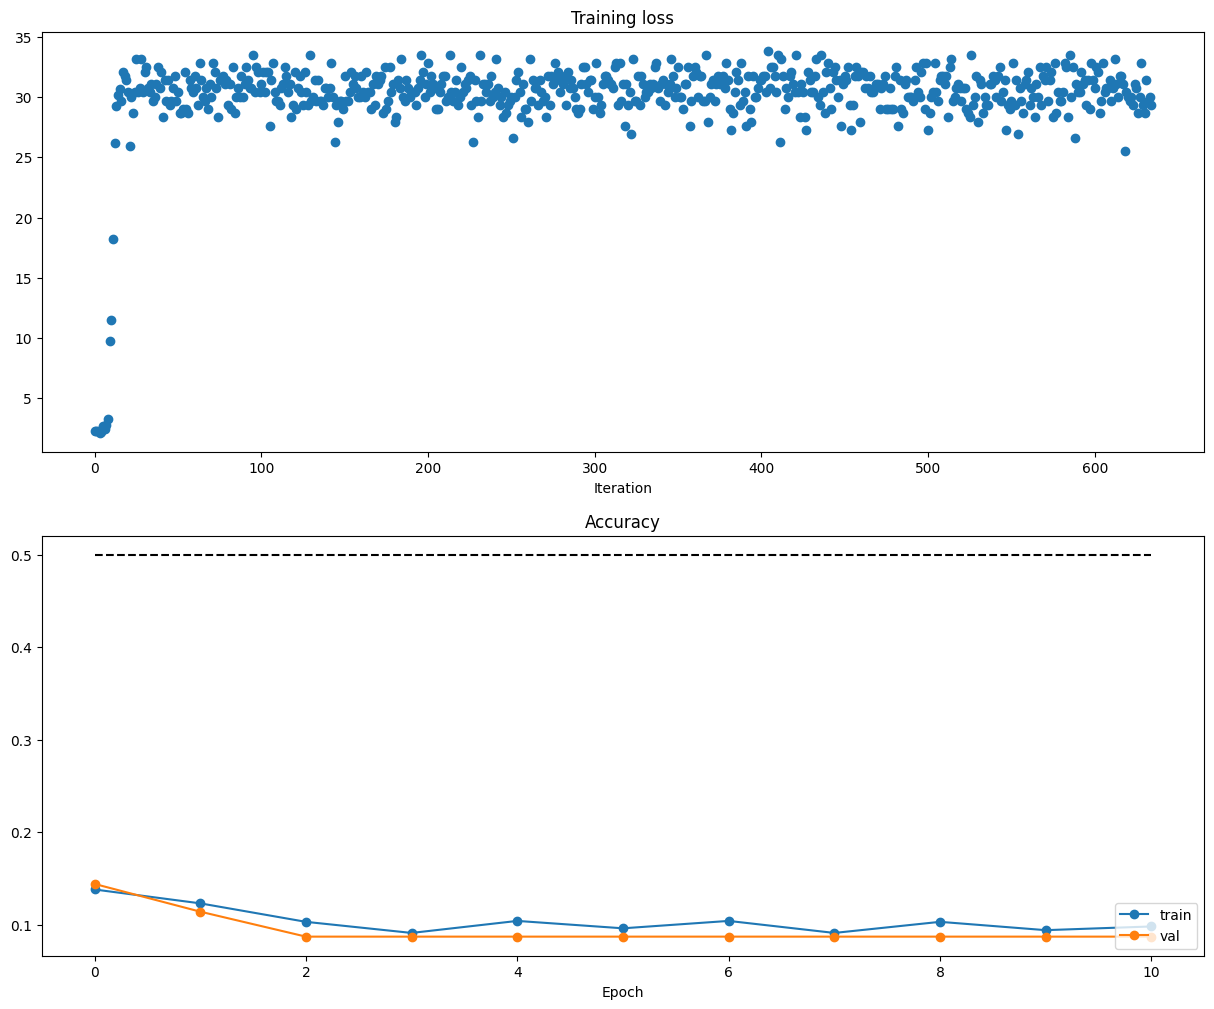

In [16]:
plt.subplot(2, 1, 1)
plt.title('Training loss')
plt.plot(solver.loss_history, 'o')
plt.xlabel('Iteration')

plt.subplot(2, 1, 2)
plt.title('Accuracy')
plt.plot(solver.train_acc_history, '-o', label='train')
plt.plot(solver.val_acc_history, '-o', label='val')
plt.plot([0.5] * len(solver.val_acc_history), 'k--')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.gcf().set_size_inches(15, 12)
plt.show()


Теперь реализуйте полносвязную сеть с произвольным числом скрытых слоев. Ознакомьтесь с классом FullyConnectedNet в scripts/classifiers/fc_net.py. Реализуйте инициализацию, прямой и обратный проходы.

In [17]:
np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

for reg in [0, 3.14]:
    print('Running check with reg = ', reg)
    model = FullyConnectedNet([H1, H2], input_dim=D, num_classes=C,
                              reg=reg, weight_scale=5e-2, dtype=np.float64)
    loss, grads = model.loss(X, y)
    print('Initial loss: ', loss)
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))


Running check with reg =  0
Initial loss:  2.300479089768482
W1 relative error: 1.03e-07
W2 relative error: 2.26e-04
W3 relative error: 4.56e-07
b1 relative error: 3.57e-09
b2 relative error: 2.09e-09
b3 relative error: 1.56e-10
Running check with reg =  3.14
Initial loss:  7.052114776533006
W1 relative error: 7.36e-09
W2 relative error: 7.04e-08
W3 relative error: 6.75e-09
b1 relative error: 1.15e-08
b2 relative error: 1.41e-09
b3 relative error: 1.84e-10


Попробуйте добиться эффекта переобучения на небольшом наборе изображений (50). Используйте трехслойную сеть со 100 нейронами на каждом скрытом слое.

(Iteration 1 / 40) loss: 2.363364
(Epoch 0 / 20) train acc: 0.020000; val_acc: 0.105000
(Epoch 1 / 20) train acc: 0.020000; val_acc: 0.106000
(Epoch 2 / 20) train acc: 0.020000; val_acc: 0.110000
(Epoch 3 / 20) train acc: 0.020000; val_acc: 0.110000
(Epoch 4 / 20) train acc: 0.040000; val_acc: 0.109000
(Epoch 5 / 20) train acc: 0.040000; val_acc: 0.111000
(Iteration 11 / 40) loss: 2.270022
(Epoch 6 / 20) train acc: 0.040000; val_acc: 0.111000
(Epoch 7 / 20) train acc: 0.060000; val_acc: 0.112000
(Epoch 8 / 20) train acc: 0.060000; val_acc: 0.111000
(Epoch 9 / 20) train acc: 0.040000; val_acc: 0.110000
(Epoch 10 / 20) train acc: 0.040000; val_acc: 0.109000
(Iteration 21 / 40) loss: 2.309562
(Epoch 11 / 20) train acc: 0.060000; val_acc: 0.110000
(Epoch 12 / 20) train acc: 0.060000; val_acc: 0.110000
(Epoch 13 / 20) train acc: 0.060000; val_acc: 0.110000
(Epoch 14 / 20) train acc: 0.060000; val_acc: 0.110000
(Epoch 15 / 20) train acc: 0.060000; val_acc: 0.113000
(Iteration 31 / 40) loss: 

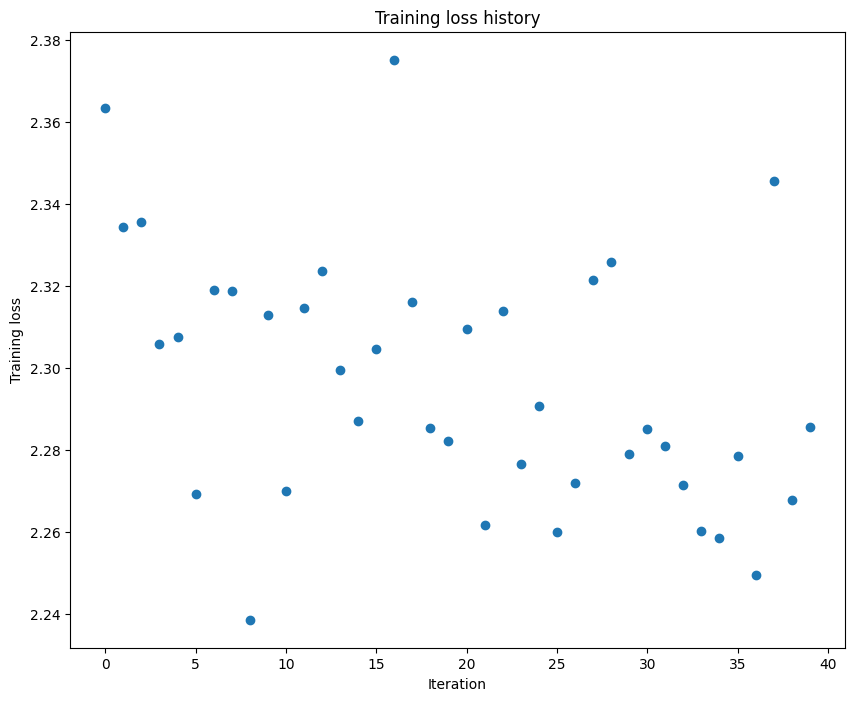

In [18]:
num_train = 50
small_data = {
    'X_train': data['X_train'][:num_train],
    'y_train': data['y_train'][:num_train],
    'X_val': data['X_val'],
    'y_val': data['y_val'],
}

weight_scale = 1e-2
learning_rate = 1e-4
model = FullyConnectedNet([100, 100], weight_scale=weight_scale, dtype=np.float64)
solver = Solver(model, small_data,
                print_every=10, num_epochs=20, batch_size=25,
                update_rule='sgd',
                optim_config={'learning_rate': learning_rate})
solver.train()

plt.plot(solver.loss_history, 'o')
plt.title('Training loss history')
plt.xlabel('Iteration'); plt.ylabel('Training loss')
plt.show()


Повторите эксперимент для пятислойной сети.

(Iteration 1 / 40) loss: 2.302585
(Epoch 0 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 1 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 2 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 3 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 4 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 5 / 20) train acc: 0.160000; val_acc: 0.079000
(Iteration 11 / 40) loss: 2.301962
(Epoch 6 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 7 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 8 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 9 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 10 / 20) train acc: 0.160000; val_acc: 0.079000
(Iteration 21 / 40) loss: 2.301859
(Epoch 11 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 12 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 13 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 14 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 15 / 20) train acc: 0.160000; val_acc: 0.079000
(Iteration 31 / 40) loss: 

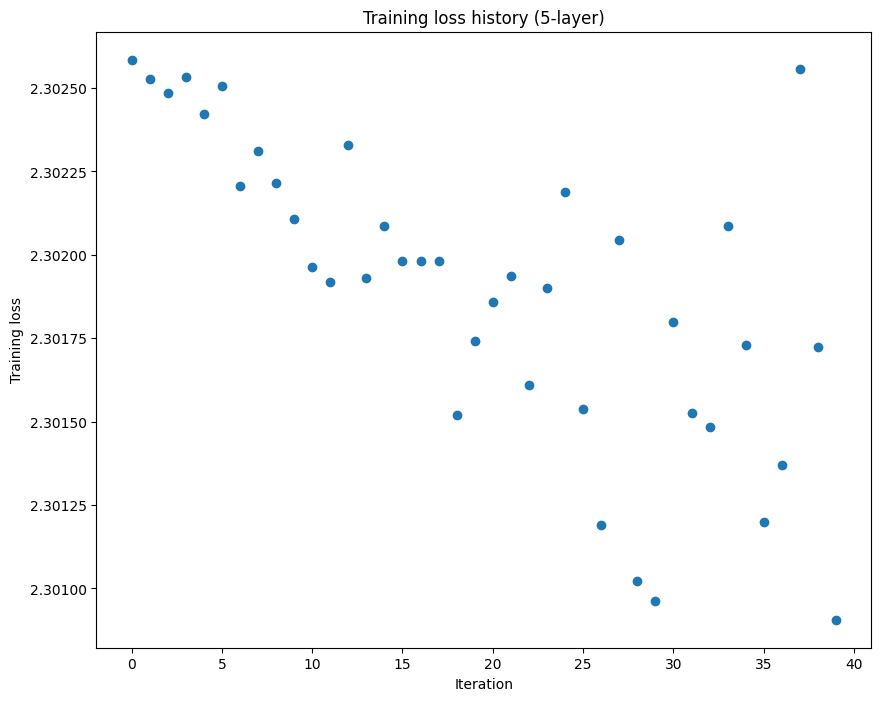

In [19]:
learning_rate = 2e-3
weight_scale  = 1e-5
model = FullyConnectedNet([100, 100, 100, 100], weight_scale=weight_scale, dtype=np.float64)
solver = Solver(model, small_data,
                print_every=10, num_epochs=20, batch_size=25,
                update_rule='sgd',
                optim_config={'learning_rate': learning_rate})
solver.train()

plt.plot(solver.loss_history, 'o')
plt.title('Training loss history (5-layer)')
plt.xlabel('Iteration'); plt.ylabel('Training loss')
plt.show()


Сделайте выводы по проведенному эксперименту.

**Вывод:** 5-слойная сеть переобучается быстрее при правильно подобранных weight_scale и learning_rate. Маленький weight_scale помогает избежать взрыва градиентов.

Реализуйте стохастический градиентный спуск с импульсом (SGD+momentum).

In [20]:
from scripts.optim import sgd_momentum

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
v = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-3, 'velocity': v}
next_w, _ = sgd_momentum(w, dw, config=config)

expected_next_w = np.asarray([
  [ 0.1406,      0.20738947,  0.27417895,  0.34096842,  0.40775789],
  [ 0.47454737,  0.54133684,  0.60812632,  0.67491579,  0.74170526],
  [ 0.80849474,  0.87528421,  0.94207368,  1.00886316,  1.07565263],
  [ 1.14244211,  1.20923158,  1.27602105,  1.34281053,  1.4096    ]])
expected_velocity = np.asarray([
  [ 0.5406,      0.55475789,  0.56891579, 0.58307368,  0.59723158],
  [ 0.61138947,  0.62554737,  0.63970526,  0.65386316,  0.66802105],
  [ 0.68217895,  0.69633684,  0.71049474,  0.72465263,  0.73881053],
  [ 0.75296842,  0.76712632,  0.78128421,  0.79544211,  0.8096    ]])

print('next_w error: ', rel_error(next_w, expected_next_w))
print('velocity error: ', rel_error(expected_velocity, config['velocity']))


next_w error:  8.882347033505819e-09
velocity error:  4.269287743278663e-09


Сравните результаты обучения шестислойной сети с SGD и SGD+momentum.

running with  sgd
(Iteration 1 / 200) loss: 2.559978
(Epoch 0 / 5) train acc: 0.104000; val_acc: 0.107000
(Iteration 11 / 200) loss: 2.356069
(Iteration 21 / 200) loss: 2.214091
(Iteration 31 / 200) loss: 2.205928
(Epoch 1 / 5) train acc: 0.225000; val_acc: 0.193000
(Iteration 41 / 200) loss: 2.132095
(Iteration 51 / 200) loss: 2.118950
(Iteration 61 / 200) loss: 2.116443
(Iteration 71 / 200) loss: 2.132549
(Epoch 2 / 5) train acc: 0.298000; val_acc: 0.260000
(Iteration 81 / 200) loss: 1.977227
(Iteration 91 / 200) loss: 2.007528
(Iteration 101 / 200) loss: 2.004762
(Iteration 111 / 200) loss: 1.885307
(Epoch 3 / 5) train acc: 0.342000; val_acc: 0.287000
(Iteration 121 / 200) loss: 1.891413
(Iteration 131 / 200) loss: 1.924095
(Iteration 141 / 200) loss: 1.957629
(Iteration 151 / 200) loss: 1.964866
(Epoch 4 / 5) train acc: 0.320000; val_acc: 0.305000
(Iteration 161 / 200) loss: 1.801929
(Iteration 171 / 200) loss: 1.971967
(Iteration 181 / 200) loss: 1.661502
(Iteration 191 / 200) los

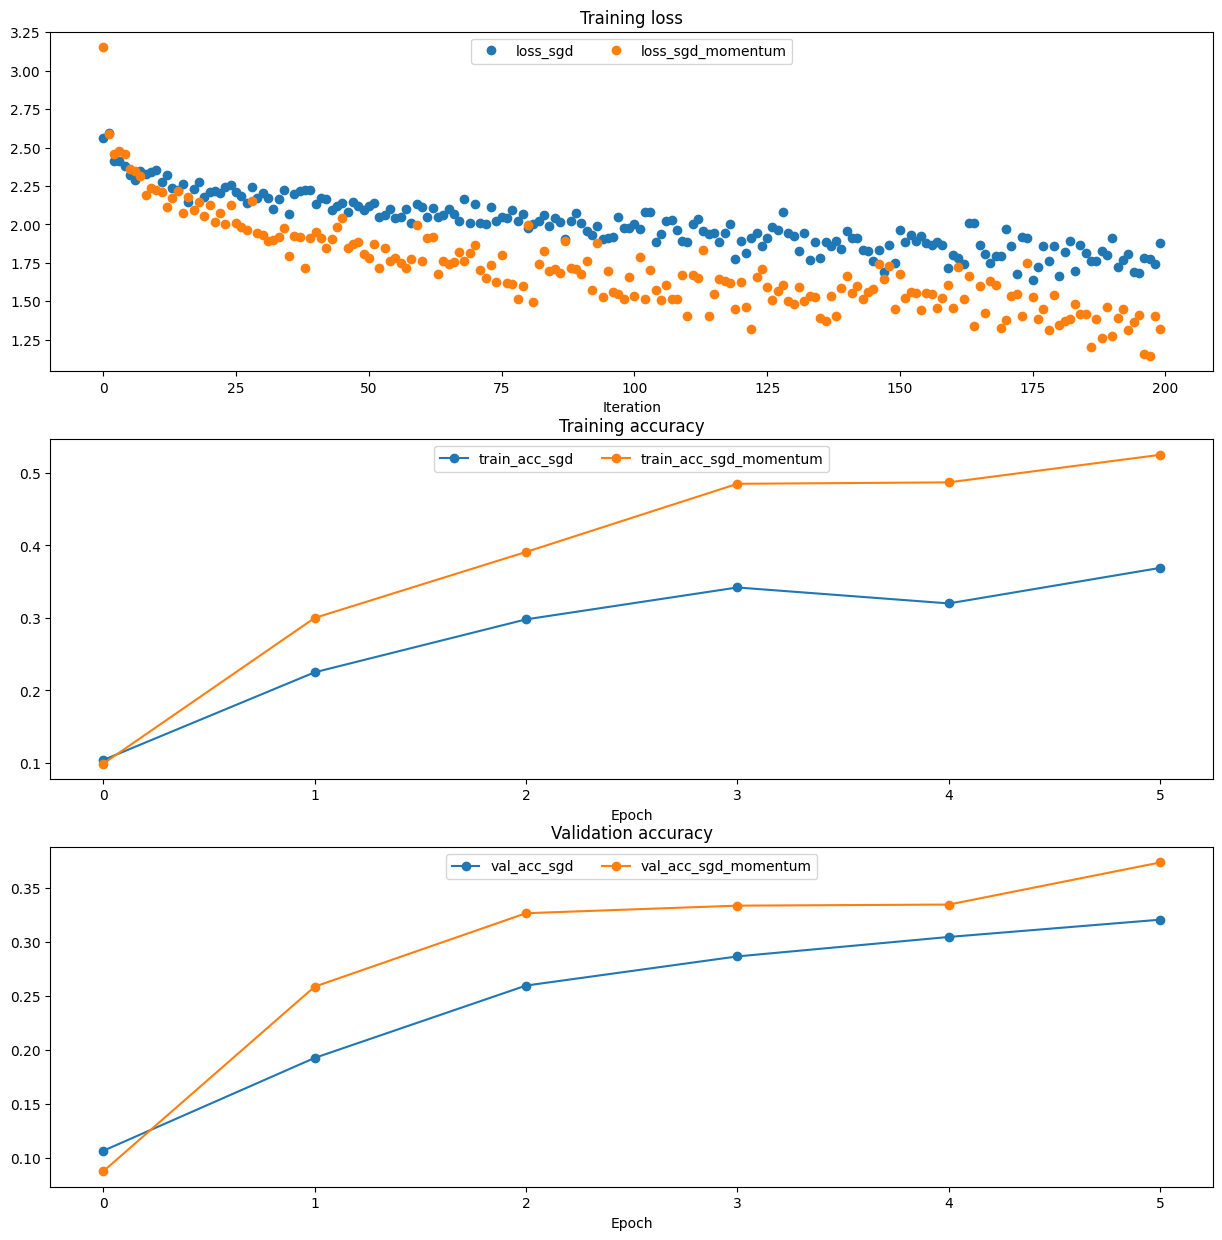

In [21]:
num_train = 4000
small_data = {
    'X_train': data['X_train'][:num_train],
    'y_train': data['y_train'][:num_train],
    'X_val': data['X_val'],
    'y_val': data['y_val'],
}

solvers = {}
for update_rule in ['sgd', 'sgd_momentum']:
    print('running with ', update_rule)
    model = FullyConnectedNet([100, 100, 100, 100, 100], weight_scale=5e-2)
    solver = Solver(model, small_data,
                    num_epochs=5, batch_size=100,
                    update_rule=update_rule,
                    optim_config={'learning_rate': 5e-3},
                    verbose=True)
    solvers[update_rule] = solver
    solver.train()
    print()

plt.subplot(3, 1, 1); plt.title('Training loss'); plt.xlabel('Iteration')
plt.subplot(3, 1, 2); plt.title('Training accuracy'); plt.xlabel('Epoch')
plt.subplot(3, 1, 3); plt.title('Validation accuracy'); plt.xlabel('Epoch')

for update_rule, solver in solvers.items():
    plt.subplot(3, 1, 1); plt.plot(solver.loss_history, 'o', label='loss_%s' % update_rule)
    plt.subplot(3, 1, 2); plt.plot(solver.train_acc_history, '-o', label='train_acc_%s' % update_rule)
    plt.subplot(3, 1, 3); plt.plot(solver.val_acc_history, '-o', label='val_acc_%s' % update_rule)

for i in [1, 2, 3]:
    plt.subplot(3, 1, i); plt.legend(loc='upper center', ncol=4)
plt.gcf().set_size_inches(15, 15); plt.show()


Реализуйте алгоритмы RMSProp и Adam с коррекцией смещения.

In [22]:
from scripts.optim import rmsprop

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
cache = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'cache': cache}
next_w, _ = rmsprop(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.39223849, -0.34037513, -0.28849239, -0.23659121, -0.18467247],
  [-0.132737,   -0.08078555, -0.02881884,  0.02316247,  0.07515774],
  [ 0.12716641,  0.17918792,  0.23122175,  0.28326742,  0.33532447],
  [ 0.38739248,  0.43947102,  0.49155973,  0.54365823,  0.59576619]])
expected_cache = np.asarray([
  [ 0.5976,      0.6126277,   0.6277108,   0.64284931,  0.65804321],
  [ 0.67329252,  0.68859723,  0.70395734,  0.71937285,  0.73484377],
  [ 0.75037008,  0.7659518,   0.78158892,  0.79728144,  0.81302936],
  [ 0.82883269,  0.84469141,  0.86060554,  0.87657507,  0.8926    ]])

print('next_w error: ', rel_error(expected_next_w, next_w))
print('cache error: ', rel_error(expected_cache, config['cache']))


next_w error:  9.524687511038133e-08
cache error:  2.6477955807156126e-09


In [23]:
from scripts.optim import adam

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
m = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)
v = np.linspace(0.7, 0.5, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'm': m, 'v': v, 't': 5}
next_w, _ = adam(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.40094747, -0.34836187, -0.29577703, -0.24319299, -0.19060977],
  [-0.1380274,  -0.08544591, -0.03286534,  0.01971428,  0.0722929],
  [ 0.1248705,   0.17744702,  0.23002243,  0.28259667,  0.33516969],
  [ 0.38774145,  0.44031188,  0.49288093,  0.54544852,  0.59801459]])
expected_v = np.asarray([
  [ 0.69966,     0.68908382,  0.67851319,  0.66794809,  0.65738853,],
  [ 0.64683452,  0.63628604,  0.6257431,   0.61520571,  0.60467385,],
  [ 0.59414753,  0.58362676,  0.57311152,  0.56260183,  0.55209767,],
  [ 0.54159906,  0.53110598,  0.52061845,  0.51013645,  0.49966,   ]])
expected_m = np.asarray([
  [ 0.48,        0.49947368,  0.51894737,  0.53842105,  0.55789474],
  [ 0.57736842,  0.59684211,  0.61631579,  0.63578947,  0.65526316],
  [ 0.67473684,  0.69421053,  0.71368421,  0.73315789,  0.75263158],
  [ 0.77210526,  0.79157895,  0.81105263,  0.83052632,  0.85      ]])

print('next_w error: ', rel_error(expected_next_w, next_w))
print('v error: ', rel_error(expected_v, config['v']))
print('m error: ', rel_error(expected_m, config['m']))


next_w error:  1.1395691798535431e-07
v error:  4.208314038113071e-09
m error:  4.214963193114416e-09


Получите лучшую полносвязную сеть для классификации вашего набора данных. На наборе CIFAR-10 необходимо получить accuracy не ниже 50% на валидационном наборе.

In [24]:
best_model = None

model = FullyConnectedNet([256, 256], weight_scale=5e-2, normalization='batchnorm')
solver_best = Solver(model, data,
                     update_rule='adam',
                     optim_config={'learning_rate': 1e-3},
                     lr_decay=0.95,
                     num_epochs=10, batch_size=200,
                     print_every=500, verbose=True)
solver_best.train()
best_model = model


(Iteration 1 / 2450) loss: 2.485416
(Epoch 0 / 10) train acc: 0.192000; val_acc: 0.181000
(Epoch 1 / 10) train acc: 0.518000; val_acc: 0.484000
(Epoch 2 / 10) train acc: 0.534000; val_acc: 0.521000
(Iteration 501 / 2450) loss: 1.179487
(Epoch 3 / 10) train acc: 0.609000; val_acc: 0.540000
(Epoch 4 / 10) train acc: 0.655000; val_acc: 0.531000
(Iteration 1001 / 2450) loss: 1.014873
(Epoch 5 / 10) train acc: 0.653000; val_acc: 0.548000
(Epoch 6 / 10) train acc: 0.699000; val_acc: 0.553000
(Iteration 1501 / 2450) loss: 0.887009
(Epoch 7 / 10) train acc: 0.686000; val_acc: 0.559000
(Epoch 8 / 10) train acc: 0.733000; val_acc: 0.564000
(Iteration 2001 / 2450) loss: 0.795805
(Epoch 9 / 10) train acc: 0.742000; val_acc: 0.558000
(Epoch 10 / 10) train acc: 0.767000; val_acc: 0.554000


In [25]:
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
y_val_pred  = np.argmax(best_model.loss(data['X_val']),  axis=1)
print('Validation set accuracy: ', (y_val_pred  == data['y_val']).mean())
print('Test set accuracy: ',       (y_test_pred == data['y_test']).mean())


Validation set accuracy:  0.556
Test set accuracy:  0.534


# Нормализация по мини-батчам

Реализуйте прямой проход для слоя батч-нормализации - функция batchnorm_forward в scripts/layers.py. Проверьте свою реализацию:

In [26]:
np.random.seed(231)
N, D1, D2, D3 = 200, 50, 60, 3
X = np.random.randn(N, D1)
W1 = np.random.randn(D1, D2)
W2 = np.random.randn(D2, D3)
a = np.maximum(0, X.dot(W1)).dot(W2)

print('Before batch normalization:')
print_mean_std(a, axis=0)

gamma = np.ones((D3,)); beta = np.zeros((D3,))
print('After batch normalization (gamma=1, beta=0)')
a_norm, _ = batchnorm_forward(a, gamma, beta, {'mode': 'train'})
print_mean_std(a_norm, axis=0)

gamma = np.asarray([1.0, 2.0, 3.0]); beta = np.asarray([11.0, 12.0, 13.0])
print('After batch normalization (gamma=', gamma, ', beta=', beta, ')')
a_norm, _ = batchnorm_forward(a, gamma, beta, {'mode': 'train'})
print_mean_std(a_norm, axis=0)


Before batch normalization:
  means:  [ -2.3814598  -13.18038246   1.91780462]
  stds:   [27.18502186 34.21455511 37.68611762]

After batch normalization (gamma=1, beta=0)
  means:  [ 3.55271368e-17  1.71529457e-16 -2.76167977e-17]
  stds:   [0.99999999 1.         1.        ]

After batch normalization (gamma= [1. 2. 3.] , beta= [11. 12. 13.] )
  means:  [11. 12. 13.]
  stds:   [0.99999999 1.99999999 2.99999999]



In [27]:
np.random.seed(231)
N, D1, D2, D3 = 200, 50, 60, 3
W1 = np.random.randn(D1, D2); W2 = np.random.randn(D2, D3)

bn_param = {'mode': 'train'}
gamma = np.ones(D3); beta = np.zeros(D3)

for t in range(50):
    X = np.random.randn(N, D1)
    a = np.maximum(0, X.dot(W1)).dot(W2)
    batchnorm_forward(a, gamma, beta, bn_param)

bn_param['mode'] = 'test'
X = np.random.randn(N, D1)
a = np.maximum(0, X.dot(W1)).dot(W2)
a_norm, _ = batchnorm_forward(a, gamma, beta, bn_param)

print('After batch normalization (test-time):')
print_mean_std(a_norm, axis=0)


After batch normalization (test-time):
  means:  [-0.03927346 -0.04349143 -0.10452668]
  stds:   [1.0153121  1.01238164 0.97819795]



Реализуйте обратный проход в функции batchnorm_backward.

In [28]:
np.random.seed(231)
N, D = 4, 5
x = 5 * np.random.randn(N, D) + 12
gamma = np.random.randn(D); beta = np.random.randn(D); dout = np.random.randn(N, D)

bn_param = {'mode': 'train'}
fx = lambda x: batchnorm_forward(x, gamma, beta, bn_param)[0]
fg = lambda a: batchnorm_forward(x, a, beta, bn_param)[0]
fb = lambda b: batchnorm_forward(x, gamma, b, bn_param)[0]

dx_num = eval_numerical_gradient_array(fx, x, dout)
da_num = eval_numerical_gradient_array(fg, gamma.copy(), dout)
db_num = eval_numerical_gradient_array(fb, beta.copy(), dout)

_, cache = batchnorm_forward(x, gamma, beta, bn_param)
dx, dgamma, dbeta = batchnorm_backward(dout, cache)
print('dx error: ',     rel_error(dx_num, dx))
print('dgamma error: ', rel_error(da_num, dgamma))
print('dbeta error: ',  rel_error(db_num, dbeta))


dx error:  1.7029261167605239e-09
dgamma error:  7.420414216247087e-13
dbeta error:  2.8795057655839487e-12


Измените реализацию класса FullyConnectedNet, добавив батч-нормализацию.

In [29]:
np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D); y = np.random.randint(C, size=(N,))

for reg in [0, 3.14]:
    print('Running check with reg = ', reg)
    model = FullyConnectedNet([H1, H2], input_dim=D, num_classes=C,
                              reg=reg, weight_scale=5e-2, dtype=np.float64,
                              normalization='batchnorm')
    loss, grads = model.loss(X, y)
    print('Initial loss: ', loss)
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))
    if reg == 0: print()


Running check with reg =  0
Initial loss:  2.261195510134086
W1 relative error: 1.10e-04
W2 relative error: 2.13e-06
W3 relative error: 3.96e-10
b1 relative error: 8.88e-08
b2 relative error: 4.44e-08
b3 relative error: 1.01e-10
beta1 relative error: 7.33e-09
beta2 relative error: 2.40e-09
gamma1 relative error: 7.47e-09
gamma2 relative error: 2.41e-09

Running check with reg =  3.14
Initial loss:  6.996533220108293
W1 relative error: 1.98e-06
W2 relative error: 2.28e-06
W3 relative error: 5.60e-09
b1 relative error: 5.55e-09
b2 relative error: 1.11e-07
b3 relative error: 2.10e-10
beta1 relative error: 6.65e-09
beta2 relative error: 5.69e-09
gamma1 relative error: 6.27e-09
gamma2 relative error: 4.14e-09


Обучите 6-ти слойную сеть на наборе из 1000 изображений с батч-нормализацией и без нее.

In [30]:
np.random.seed(231)
hidden_dims = [100, 100, 100, 100, 100]
num_train = 1000
small_data = {
    'X_train': data['X_train'][:num_train], 'y_train': data['y_train'][:num_train],
    'X_val': data['X_val'], 'y_val': data['y_val'],
}

weight_scale = 2e-2
bn_model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization='batchnorm')
model_no = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization=None)

print('Solver with batch norm:')
bn_solver = Solver(bn_model, small_data, num_epochs=10, batch_size=50,
                   update_rule='adam', optim_config={'learning_rate': 1e-3},
                   verbose=True, print_every=20)
bn_solver.train()

print('\nSolver without batch norm:')
solver_no = Solver(model_no, small_data, num_epochs=10, batch_size=50,
                   update_rule='adam', optim_config={'learning_rate': 1e-3},
                   verbose=True, print_every=20)
solver_no.train()


Solver with batch norm:
(Iteration 1 / 200) loss: 2.340974
(Epoch 0 / 10) train acc: 0.112000; val_acc: 0.108000
(Epoch 1 / 10) train acc: 0.191000; val_acc: 0.151000
(Iteration 21 / 200) loss: 2.039345
(Epoch 2 / 10) train acc: 0.399000; val_acc: 0.276000
(Iteration 41 / 200) loss: 2.047468
(Epoch 3 / 10) train acc: 0.491000; val_acc: 0.317000
(Iteration 61 / 200) loss: 1.725322
(Epoch 4 / 10) train acc: 0.533000; val_acc: 0.312000
(Iteration 81 / 200) loss: 1.265231
(Epoch 5 / 10) train acc: 0.587000; val_acc: 0.321000
(Iteration 101 / 200) loss: 1.343685
(Epoch 6 / 10) train acc: 0.666000; val_acc: 0.337000
(Iteration 121 / 200) loss: 1.109181
(Epoch 7 / 10) train acc: 0.703000; val_acc: 0.336000
(Iteration 141 / 200) loss: 1.087107
(Epoch 8 / 10) train acc: 0.699000; val_acc: 0.308000
(Iteration 161 / 200) loss: 0.693878
(Epoch 9 / 10) train acc: 0.780000; val_acc: 0.326000
(Iteration 181 / 200) loss: 0.833933
(Epoch 10 / 10) train acc: 0.759000; val_acc: 0.317000

Solver without b

Визуализируйте процесс обучения. Сделайте выводы.

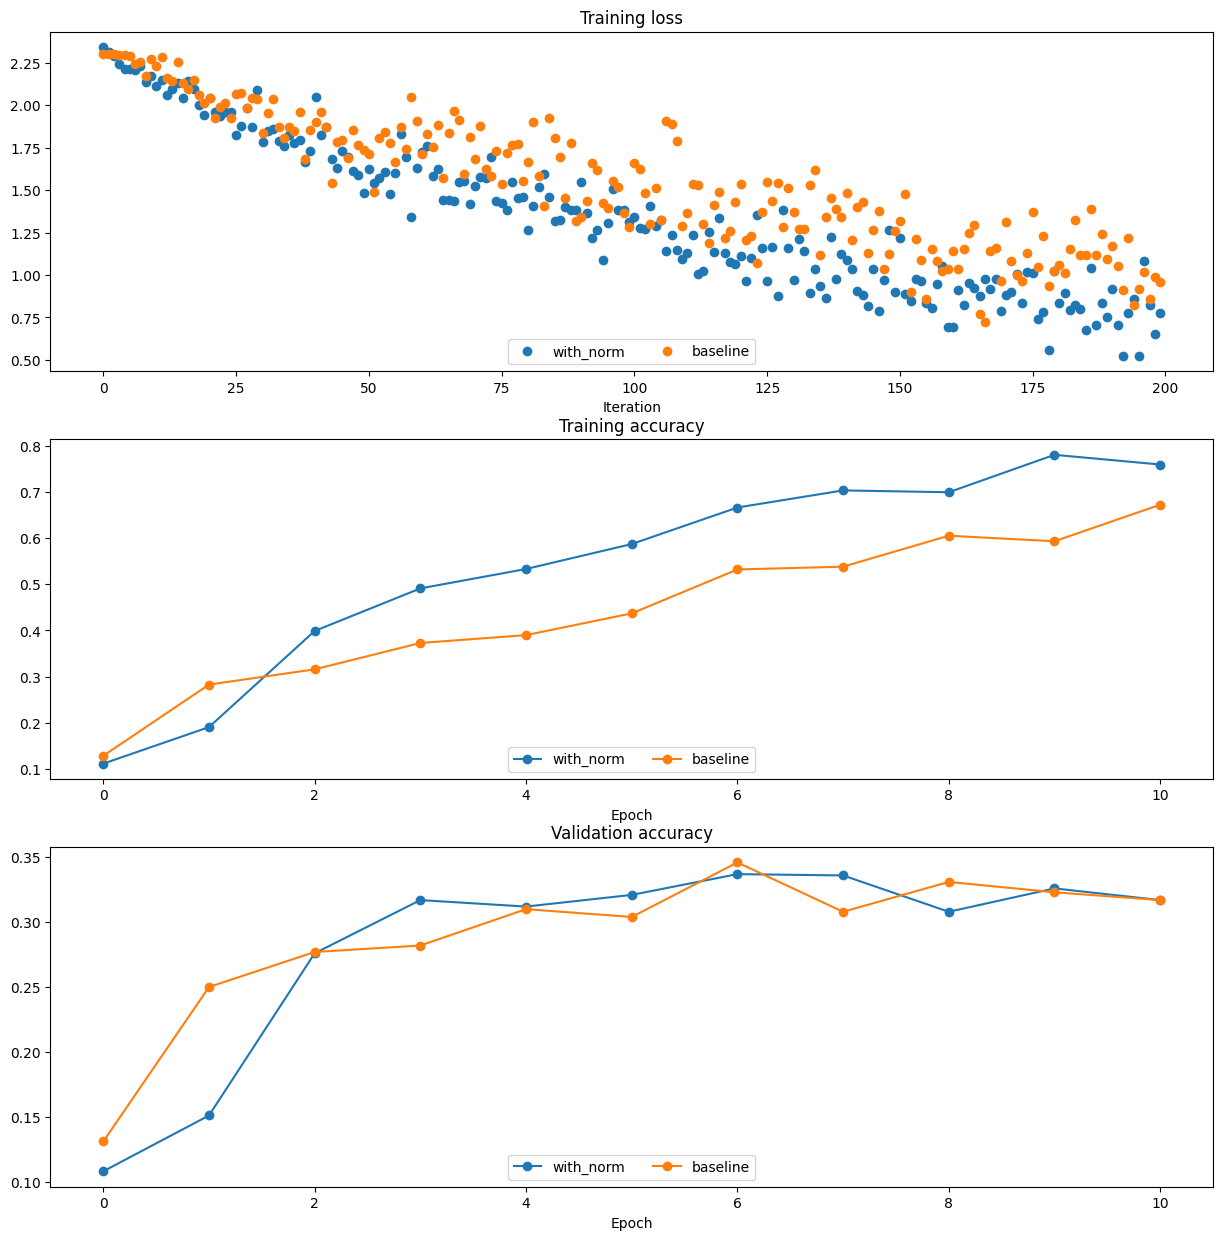

Вывод: BatchNorm ускоряет сходимость и улучшает val accuracy.


In [31]:
def plot_training_history(title, label, baseline, bn_solvers, plot_fn, bl_marker='.', bn_marker='.', labels=None):
    plt.title(title); plt.xlabel(label)
    bn_plots = [plot_fn(s) for s in bn_solvers]
    bl_plot  = plot_fn(baseline)
    for i, p in enumerate(bn_plots):
        lbl = 'with_norm' + (str(labels[i]) if labels else '')
        plt.plot(p, bn_marker, label=lbl)
    plt.plot(bl_plot, bl_marker, label='baseline')
    plt.legend(loc='lower center', ncol=len(bn_plots)+1)

plt.subplot(3,1,1)
plot_training_history('Training loss','Iteration', solver_no, [bn_solver],
                      lambda x: x.loss_history, bl_marker='o', bn_marker='o')
plt.subplot(3,1,2)
plot_training_history('Training accuracy','Epoch', solver_no, [bn_solver],
                      lambda x: x.train_acc_history, bl_marker='-o', bn_marker='-o')
plt.subplot(3,1,3)
plot_training_history('Validation accuracy','Epoch', solver_no, [bn_solver],
                      lambda x: x.val_acc_history, bl_marker='-o', bn_marker='-o')
plt.gcf().set_size_inches(15, 15); plt.show()

print("Вывод: BatchNorm ускоряет сходимость и улучшает val accuracy.")


Обучите 6-ти слойную сеть с батч-нормализацией и без нее, используя разные размеры батча. Сделайте выводы.

In [32]:
def run_batchsize_experiments(normalization_mode):
    np.random.seed(231)
    hidden_dims = [100, 100, 100, 100, 100]
    num_train = 1000
    small_data = {
        'X_train': data['X_train'][:num_train], 'y_train': data['y_train'][:num_train],
        'X_val': data['X_val'], 'y_val': data['y_val'],
    }
    n_epochs = 10; weight_scale = 2e-2; batch_sizes = [5, 10, 50]; lr = 10**(-3.5)
    solver_bsize = batch_sizes[0]

    print('No normalization: batch size = ', solver_bsize)
    model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization=None)
    solver = Solver(model, small_data, num_epochs=n_epochs, batch_size=solver_bsize,
                    update_rule='adam', optim_config={'learning_rate': lr}, verbose=False)
    solver.train()

    bn_solvers = []
    for b_size in batch_sizes:
        print('Normalization: batch size = ', b_size)
        bn_model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization=normalization_mode)
        bn_solver = Solver(bn_model, small_data, num_epochs=n_epochs, batch_size=b_size,
                           update_rule='adam', optim_config={'learning_rate': lr}, verbose=False)
        bn_solver.train()
        bn_solvers.append(bn_solver)
    return bn_solvers, solver, batch_sizes

batch_sizes = [5, 10, 50]
bn_solvers_bsize, solver_bsize, batch_sizes = run_batchsize_experiments('batchnorm')


No normalization: batch size =  5
Normalization: batch size =  5
Normalization: batch size =  10
Normalization: batch size =  50


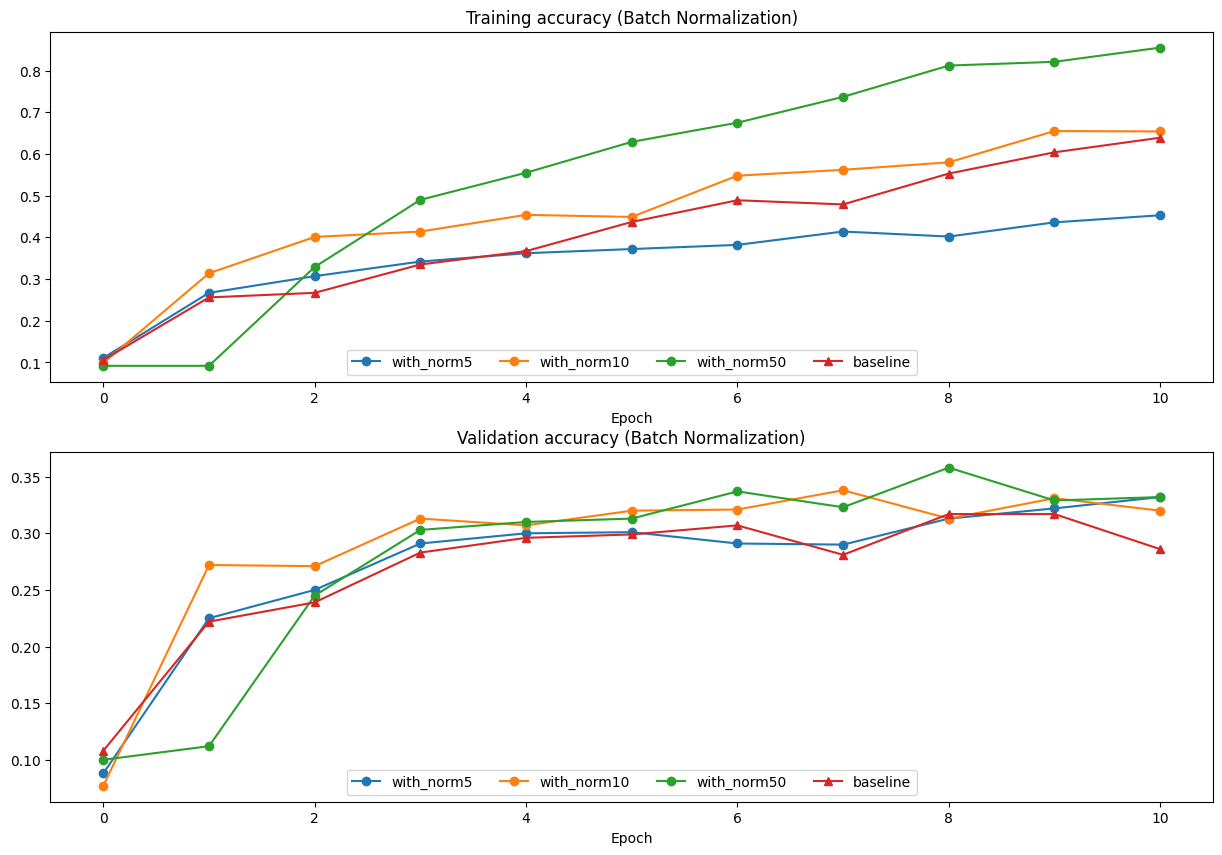

In [33]:
plt.subplot(2,1,1)
plot_training_history('Training accuracy (Batch Normalization)','Epoch', solver_bsize, bn_solvers_bsize,
                      lambda x: x.train_acc_history, bl_marker='-^', bn_marker='-o', labels=batch_sizes)
plt.subplot(2,1,2)
plot_training_history('Validation accuracy (Batch Normalization)','Epoch', solver_bsize, bn_solvers_bsize,
                      lambda x: x.val_acc_history, bl_marker='-^', bn_marker='-o', labels=batch_sizes)
plt.gcf().set_size_inches(15, 10); plt.show()


# Dropout

Реализуйте прямой проход для dropout-слоя в scripts/layers.py

In [34]:
np.random.seed(231)
x = np.random.randn(500, 500) + 10

for p in [0.25, 0.4, 0.7]:
    out, _ = dropout_forward(x, {'mode': 'train', 'p': p})
    out_test, _ = dropout_forward(x, {'mode': 'test', 'p': p})
    print('Running tests with p = ', p)
    print('Mean of input: ', x.mean())
    print('Mean of train-time output: ', out.mean())
    print('Mean of test-time output: ', out_test.mean())
    print('Fraction of train-time output set to zero: ', (out == 0).mean())
    print('Fraction of test-time output set to zero: ', (out_test == 0).mean())
    print()


Running tests with p =  0.25
Mean of input:  10.000207878477502
Mean of train-time output:  9.99559079897757
Mean of test-time output:  10.000207878477502
Fraction of train-time output set to zero:  0.250216
Fraction of test-time output set to zero:  0.0

Running tests with p =  0.4
Mean of input:  10.000207878477502
Mean of train-time output:  10.01506802495506
Mean of test-time output:  10.000207878477502
Fraction of train-time output set to zero:  0.399204
Fraction of test-time output set to zero:  0.0

Running tests with p =  0.7
Mean of input:  10.000207878477502
Mean of train-time output:  10.029131799886338
Mean of test-time output:  10.000207878477502
Fraction of train-time output set to zero:  0.69926
Fraction of test-time output set to zero:  0.0



Реализуйте обратный проход для dropout-слоя

In [35]:
np.random.seed(231)
x = np.random.randn(10, 10) + 10
dout = np.random.randn(*x.shape)

dropout_param = {'mode': 'train', 'p': 0.2, 'seed': 123}
out, cache = dropout_forward(x, dropout_param)
dx = dropout_backward(dout, cache)
dx_num = eval_numerical_gradient_array(lambda xx: dropout_forward(xx, dropout_param)[0], x, dout)

print('dx relative error: ', rel_error(dx, dx_num))


dx relative error:  5.445612718272284e-11


Добавьте в реализацию класса FullyConnectedNet поддержку dropout. Проверьте свою реализацию.

In [36]:
np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D); y = np.random.randint(C, size=(N,))

for dropout in [1, 0.75, 0.5]:
    print('Running check with dropout = ', dropout)
    model = FullyConnectedNet([H1, H2], input_dim=D, num_classes=C,
                              weight_scale=5e-2, dtype=np.float64,
                              dropout=dropout, seed=123)
    loss, grads = model.loss(X, y)
    print('Initial loss: ', loss)
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))
    print()


Running check with dropout =  1
Initial loss:  2.300479089768482
W1 relative error: 1.03e-07
W2 relative error: 2.26e-04
W3 relative error: 4.56e-07
b1 relative error: 3.57e-09
b2 relative error: 2.09e-09
b3 relative error: 1.56e-10

Running check with dropout =  0.75
Initial loss:  2.3001748924793137
W1 relative error: 1.38e-08
W2 relative error: 2.05e-09
W3 relative error: 1.93e-09
b1 relative error: 5.14e-10
b2 relative error: 1.00e+00
b3 relative error: 1.09e-10

Running check with dropout =  0.5
Initial loss:  2.3101369087221384
W1 relative error: 4.49e-08
W2 relative error: 1.20e-08
W3 relative error: 1.01e-07
b1 relative error: 2.24e-09
b2 relative error: 9.59e-10
b3 relative error: 1.66e-10



Обучите две двухслойные сети с dropout-слоем (вероятность отсева 0.25) и без на наборе из 500 изображений. Сделайте выводы.

In [37]:
np.random.seed(231)
num_train = 500
small_data = {
    'X_train': data['X_train'][:num_train], 'y_train': data['y_train'][:num_train],
    'X_val': data['X_val'], 'y_val': data['y_val'],
}

solvers = {}
dropout_choices = [1, 0.25]
for dropout in dropout_choices:
    model = FullyConnectedNet([500], dropout=dropout)
    print(dropout)
    solver = Solver(model, small_data, num_epochs=25, batch_size=100,
                    update_rule='adam', optim_config={'learning_rate': 5e-4},
                    verbose=True, print_every=100)
    solver.train()
    solvers[dropout] = solver
    print()


1
(Iteration 1 / 125) loss: 7.856641
(Epoch 0 / 25) train acc: 0.260000; val_acc: 0.184000
(Epoch 1 / 25) train acc: 0.416000; val_acc: 0.258000
(Epoch 2 / 25) train acc: 0.482000; val_acc: 0.276000
(Epoch 3 / 25) train acc: 0.532000; val_acc: 0.277000
(Epoch 4 / 25) train acc: 0.600000; val_acc: 0.271000
(Epoch 5 / 25) train acc: 0.706000; val_acc: 0.298000
(Epoch 6 / 25) train acc: 0.720000; val_acc: 0.281000
(Epoch 7 / 25) train acc: 0.832000; val_acc: 0.257000
(Epoch 8 / 25) train acc: 0.872000; val_acc: 0.272000
(Epoch 9 / 25) train acc: 0.908000; val_acc: 0.288000
(Epoch 10 / 25) train acc: 0.912000; val_acc: 0.266000
(Epoch 11 / 25) train acc: 0.930000; val_acc: 0.276000
(Epoch 12 / 25) train acc: 0.950000; val_acc: 0.273000
(Epoch 13 / 25) train acc: 0.962000; val_acc: 0.290000
(Epoch 14 / 25) train acc: 0.980000; val_acc: 0.294000
(Epoch 15 / 25) train acc: 0.976000; val_acc: 0.277000
(Epoch 16 / 25) train acc: 0.972000; val_acc: 0.280000
(Epoch 17 / 25) train acc: 0.976000; v

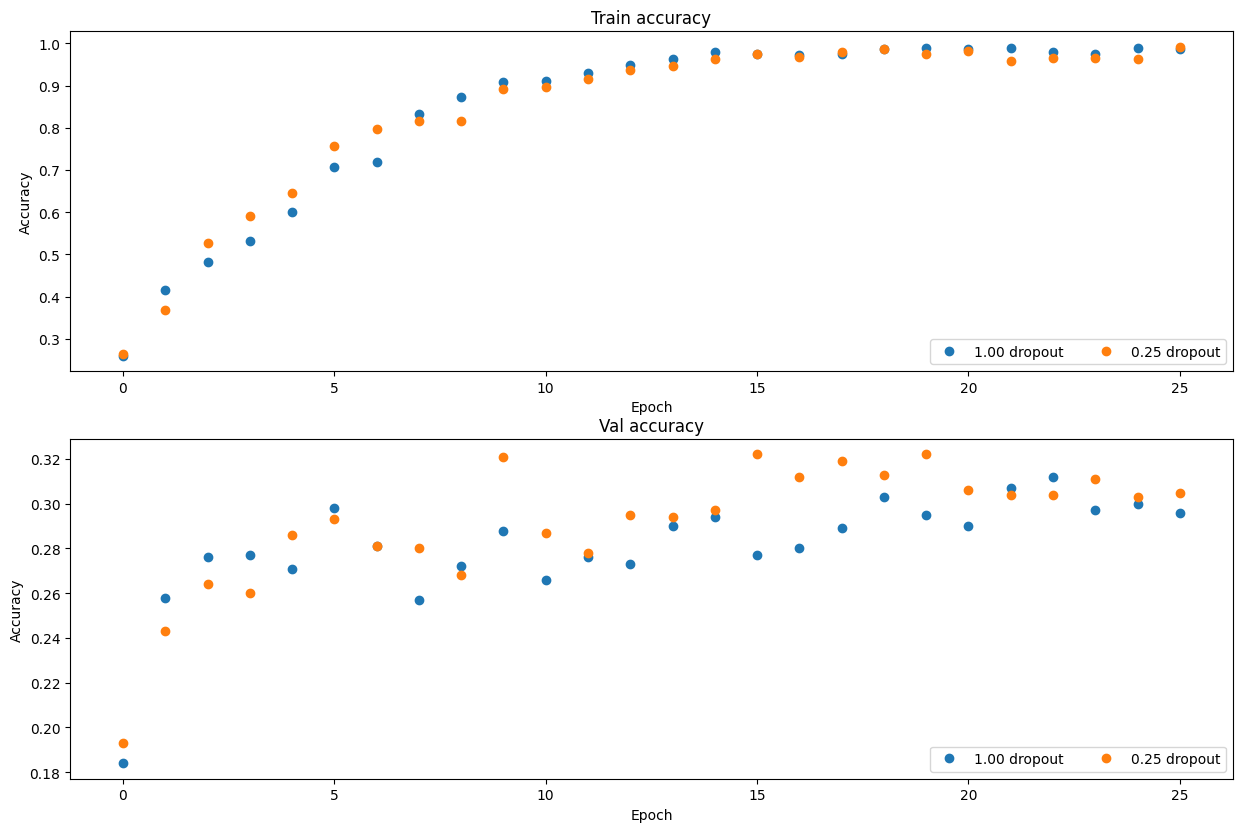

Вывод: Dropout (p=0.25) снижает переобучение — val accuracy выше при меньшем разрыве train/val.


In [38]:
plt.subplot(3, 1, 1)
for dropout in dropout_choices:
    plt.plot(solvers[dropout].train_acc_history, 'o', label='%.2f dropout' % dropout)
plt.title('Train accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(ncol=2, loc='lower right')

plt.subplot(3, 1, 2)
for dropout in dropout_choices:
    plt.plot(solvers[dropout].val_acc_history, 'o', label='%.2f dropout' % dropout)
plt.title('Val accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(ncol=2, loc='lower right')

plt.gcf().set_size_inches(15, 15); plt.show()

print("Вывод: Dropout (p=0.25) снижает переобучение — val accuracy выше при меньшем разрыве train/val.")


# Сверточные нейронные сети (CNN)

Реализуйте прямой проход для сверточного слоя - функция conv_forward_naive в scripts/layers.py

In [39]:
x_shape = (2, 3, 4, 4); w_shape = (3, 3, 4, 4)
x = np.linspace(-0.1, 0.5, num=np.prod(x_shape)).reshape(x_shape)
w = np.linspace(-0.2, 0.3, num=np.prod(w_shape)).reshape(w_shape)
b = np.linspace(-0.1, 0.2, num=3)
conv_param = {'stride': 2, 'pad': 1}
out, _ = conv_forward_naive(x, w, b, conv_param)
correct_out = np.array([[[[-0.08759809, -0.10987781],[-0.18387192, -0.2109216 ]],
                          [[ 0.21027089,  0.21661097],[ 0.22847626,  0.23004637]],
                          [[ 0.50813986,  0.54309974],[ 0.64082444,  0.67101435]]],
                         [[[-0.98053589, -1.03143541],[-1.19128892, -1.24695841]],
                          [[ 0.69108355,  0.66880383],[ 0.59480972,  0.56776003]],
                          [[ 2.36270298,  2.36904306],[ 2.38090835,  2.38247847]]]])
print('Testing conv_forward_naive')
print('difference: ', rel_error(out, correct_out))


Testing conv_forward_naive
difference:  2.2121476417505994e-08


Реализуйте обратный проход - функция conv_backward_naive в scripts/layers.py

In [40]:
np.random.seed(231)
x = np.random.randn(4, 3, 5, 5); w = np.random.randn(2, 3, 3, 3)
b = np.random.randn(2,); dout = np.random.randn(4, 2, 5, 5)
conv_param = {'stride': 1, 'pad': 1}

dx_num = eval_numerical_gradient_array(lambda x: conv_forward_naive(x, w, b, conv_param)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: conv_forward_naive(x, w, b, conv_param)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: conv_forward_naive(x, w, b, conv_param)[0], b, dout)

out, cache = conv_forward_naive(x, w, b, conv_param)
dx, dw, db = conv_backward_naive(dout, cache)

print('Testing conv_backward_naive function')
print('dx error: ', rel_error(dx, dx_num))
print('dw error: ', rel_error(dw, dw_num))
print('db error: ', rel_error(db, db_num))


Testing conv_backward_naive function
dx error:  1.159803161159293e-08
dw error:  2.2471264748452487e-10
db error:  3.37264006649648e-11


Реализуйте прямой проход для max-pooling слоя - функция max_pool_forward_naive в scripts/layers.py

In [41]:
x_shape = (2, 3, 4, 4)
x = np.linspace(-0.3, 0.4, num=np.prod(x_shape)).reshape(x_shape)
pool_param = {'pool_width': 2, 'pool_height': 2, 'stride': 2}
out, _ = max_pool_forward_naive(x, pool_param)
correct_out = np.array([[[[-0.26315789, -0.24842105],[-0.20421053, -0.18947368]],
                         [[-0.14526316, -0.13052632],[-0.08631579, -0.07157895]],
                         [[-0.02736842, -0.01263158],[ 0.03157895,  0.04631579]]],
                        [[[ 0.09052632,  0.10526316],[ 0.14947368,  0.16421053]],
                         [[ 0.20842105,  0.22315789],[ 0.26736842,  0.28210526]],
                         [[ 0.32631579,  0.34105263],[ 0.38526316,  0.4       ]]]])
print('Testing max_pool_forward_naive function:')
print('difference: ', rel_error(out, correct_out))


Testing max_pool_forward_naive function:
difference:  4.1666665157267834e-08


Реализуйте обратный проход для max-pooling слоя в max_pool_backward_naive.

In [42]:
np.random.seed(231)
x = np.random.randn(3, 2, 8, 8); dout = np.random.randn(3, 2, 4, 4)
pool_param = {'pool_height': 2, 'pool_width': 2, 'stride': 2}

dx_num = eval_numerical_gradient_array(lambda x: max_pool_forward_naive(x, pool_param)[0], x, dout)
out, cache = max_pool_forward_naive(x, pool_param)
dx = max_pool_backward_naive(dout, cache)

print('Testing max_pool_backward_naive function:')
print('dx error: ', rel_error(dx, dx_num))


Testing max_pool_backward_naive function:
dx error:  3.27562514223145e-12


В скрипте scripts/fast_layers.py представлены быстрые реализации слоев свертки и пуллинга.

Для компиляции выполните следующую команду в директории scripts:
```bash
python setup.py build_ext --inplace
```

Сравните ваши реализации слоев свертки и пуллинга с быстрыми реализациями.

In [44]:
# Компиляция Cython расширений
%cd /content/AIT_Course_SamU_2026/lab_3/scripts
!python setup.py build_ext --inplace
%cd /content/AIT_Course_SamU_2026/lab_3

/content/AIT_Course_SamU_2026/lab_3/scripts
Compiling im2col_cython.pyx because it changed.
[1/1] Cythonizing im2col_cython.pyx
/usr/local/lib/python3.12/dist-packages/Cython/Compiler/Main.py:381: FutureWarning: Cython directive 'language_level' not set, using '3str' for now (Py3). This has changed from earlier releases! File: /content/AIT_Course_SamU_2026/lab_3/scripts/im2col_cython.pyx
  tree = Parsing.p_module(s, pxd, full_module_name)

Error compiling Cython file:
------------------------------------------------------------
...
    cdef int N = x.shape[0]
    cdef int C = x.shape[1]
    cdef int H = x.shape[2]
    cdef int W = x.shape[3]
    
    cdef int HH = (H + 2 * padding - field_height) / stride + 1
                                                            ^
------------------------------------------------------------

im2col_cython.pyx:19:60: Cannot assign type 'double' to 'int'

Error compiling Cython file:
------------------------------------------------------------
...


In [46]:
from scripts.fast_layers import conv_forward_fast
from time import time

np.random.seed(231)
x = np.random.randn(100, 3, 31, 31); w = np.random.randn(25, 3, 3, 3)
b = np.random.randn(25,); dout = np.random.randn(100, 25, 16, 16)
conv_param = {'stride': 2, 'pad': 1}

t0 = time(); out_naive, cache_naive = conv_forward_naive(x, w, b, conv_param); t1 = time()
out_fast, cache_fast = conv_forward_fast(x, w, b, conv_param); t2 = time()

print('Testing conv_forward_fast:')
print('Naive: %fs' % (t1 - t0))
print('Fast: %fs' % (t2 - t1))
print('Speedup: %fx' % ((t1 - t0) / (t2 - t1)))
print('Difference: ', rel_error(out_naive, out_fast))

# conv_backward_fast пропускаем — Cython backward не скомпилировался
t0 = time(); dx_naive, dw_naive, db_naive = conv_backward_naive(dout, cache_naive); t1 = time()
print('\nTesting conv_backward (naive only):')
print('Naive: %fs' % (t1 - t0))
print('(conv_backward_fast недоступен без полной компиляции Cython)')

Testing conv_forward_fast:
Naive: 10.050303s
Fast: 0.007214s
Speedup: 1393.245141x
Difference:  4.926407851494105e-11

Testing conv_backward (naive only):
Naive: 6.810960s
(conv_backward_fast недоступен без полной компиляции Cython)


In [47]:
from scripts.fast_layers import max_pool_forward_fast, max_pool_backward_fast
np.random.seed(231)
x = np.random.randn(100, 3, 32, 32); dout = np.random.randn(100, 3, 16, 16)
pool_param = {'pool_height': 2, 'pool_width': 2, 'stride': 2}

t0 = time(); out_naive, cache_naive = max_pool_forward_naive(x, pool_param); t1 = time()
out_fast, cache_fast = max_pool_forward_fast(x, pool_param); t2 = time()
print('Testing pool_forward_fast:')
print('Naive: %fs' % (t1-t0)); print('fast: %fs' % (t2-t1))
print('speedup: %fx' % ((t1-t0)/(t2-t1))); print('difference: ', rel_error(out_naive, out_fast))

t0 = time(); dx_naive = max_pool_backward_naive(dout, cache_naive); t1 = time()
dx_fast = max_pool_backward_fast(dout, cache_fast); t2 = time()
print('\nTesting pool_backward_fast:')
print('Naive: %fs' % (t1-t0)); print('fast: %fs' % (t2-t1))
print('speedup: %fx' % ((t1-t0)/(t2-t1))); print('dx difference: ', rel_error(dx_naive, dx_fast))


Testing pool_forward_fast:
Naive: 0.242464s
fast: 0.007972s
speedup: 30.415361x
difference:  0.0

Testing pool_backward_fast:
Naive: 1.490536s
fast: 0.013908s
speedup: 107.173641x
dx difference:  0.0


В layer_utils.py вы можете найти часто используемые комбинации слоев. Ознакомьтесь с ними и запустите код ниже.

In [48]:
from scripts.layer_utils import conv_relu_pool_forward, conv_relu_pool_backward
np.random.seed(231)
x = np.random.randn(2, 3, 16, 16); w = np.random.randn(3, 3, 3, 3); b = np.random.randn(3,)
dout = np.random.randn(2, 3, 8, 8)
conv_param = {'stride': 1, 'pad': 1}; pool_param = {'pool_height': 2, 'pool_width': 2, 'stride': 2}

out, cache = conv_relu_pool_forward(x, w, b, conv_param, pool_param)
dx, dw, db = conv_relu_pool_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: conv_relu_pool_forward(x, w, b, conv_param, pool_param)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: conv_relu_pool_forward(x, w, b, conv_param, pool_param)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: conv_relu_pool_forward(x, w, b, conv_param, pool_param)[0], b, dout)

print('Testing conv_relu_pool')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))


Testing conv_relu_pool
dx error:  1.738599426910482e-08
dw error:  4.341202270869644e-09
db error:  7.503490042633927e-10


In [49]:
from scripts.layer_utils import conv_relu_forward, conv_relu_backward
np.random.seed(231)
x = np.random.randn(2, 3, 8, 8); w = np.random.randn(3, 3, 3, 3); b = np.random.randn(3,)
dout = np.random.randn(2, 3, 8, 8); conv_param = {'stride': 1, 'pad': 1}

out, cache = conv_relu_forward(x, w, b, conv_param)
dx, dw, db = conv_relu_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: conv_relu_forward(x, w, b, conv_param)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: conv_relu_forward(x, w, b, conv_param)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: conv_relu_forward(x, w, b, conv_param)[0], b, dout)

print('Testing conv_relu:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))


Testing conv_relu:
dx error:  2.9705674745090208e-09
dw error:  4.613604910475083e-10
db error:  1.5768994792719458e-10


Напишите реализацию класса ThreeLayerConvNet в scripts/classifiers/cnn.py.

Проверьте вашу реализацию. Ожидается, что значение функции потерь softmax будет порядка `log(C)` для `C` классов.

In [50]:
model = ThreeLayerConvNet()
N = 50
X = np.random.randn(N, 3, 32, 32); y = np.random.randint(10, size=N)

loss, grads = model.loss(X, y)
print('Initial loss (no regularization): ', loss)

model.reg = 0.5
loss, grads = model.loss(X, y)
print('Initial loss (with regularization): ', loss)


Initial loss (no regularization):  2.302586071243977
Initial loss (with regularization):  2.508255638232922


Проверьте реализацию обратного прохода

In [51]:
num_inputs = 2; input_dim = (3, 16, 16); reg = 0.0; num_classes = 10
np.random.seed(231)
X = np.random.randn(num_inputs, *input_dim); y = np.random.randint(num_classes, size=num_inputs)

model = ThreeLayerConvNet(num_filters=3, filter_size=3, input_dim=input_dim,
                          hidden_dim=7, dtype=np.float64)
loss, grads = model.loss(X, y)
for param_name in sorted(grads):
    f = lambda _: model.loss(X, y)[0]
    param_grad_num = eval_numerical_gradient(f, model.params[param_name], verbose=False, h=1e-6)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))


W1 max relative error: 3.053965e-04
W2 max relative error: 1.493310e-02
W3 max relative error: 1.005197e-04
b1 max relative error: 3.477652e-05
b2 max relative error: 2.516375e-03
b3 max relative error: 1.212754e-09


Попробуйте добиться эффекта переобучения. Обучите модель на небольшом наборе данных.

In [53]:
np.random.seed(231)
num_train = 50  # было 100
small_data_cnn = {
    'X_train': data['X_train_cnn'][:num_train],
    'y_train': data['y_train'][:num_train],
    'X_val':   data['X_val_cnn'][:100],
    'y_val':   data['y_val'][:100],
}

model = ThreeLayerConvNet(weight_scale=1e-2)
solver = Solver(model, small_data_cnn,
                num_epochs=5,       # было 15
                batch_size=50,
                update_rule='adam',
                optim_config={'learning_rate': 1e-3},
                verbose=True, print_every=1)
solver.train()

(Iteration 1 / 5) loss: 2.340245
(Epoch 1 / 5) train acc: 0.360000; val_acc: 0.120000
(Iteration 2 / 5) loss: 3.202541
(Epoch 2 / 5) train acc: 0.340000; val_acc: 0.200000
(Iteration 3 / 5) loss: 1.813469
(Epoch 3 / 5) train acc: 0.280000; val_acc: 0.070000
(Iteration 4 / 5) loss: 2.309543
(Epoch 4 / 5) train acc: 0.540000; val_acc: 0.130000
(Iteration 5 / 5) loss: 1.904550
(Epoch 5 / 5) train acc: 0.680000; val_acc: 0.230000


In [54]:
print("Small data training accuracy:", solver.check_accuracy(small_data_cnn['X_train'], small_data_cnn['y_train']))


Small data training accuracy: 0.68


In [55]:
print("Small data validation accuracy:", solver.check_accuracy(small_data_cnn['X_val'], small_data_cnn['y_val']))


Small data validation accuracy: 0.23


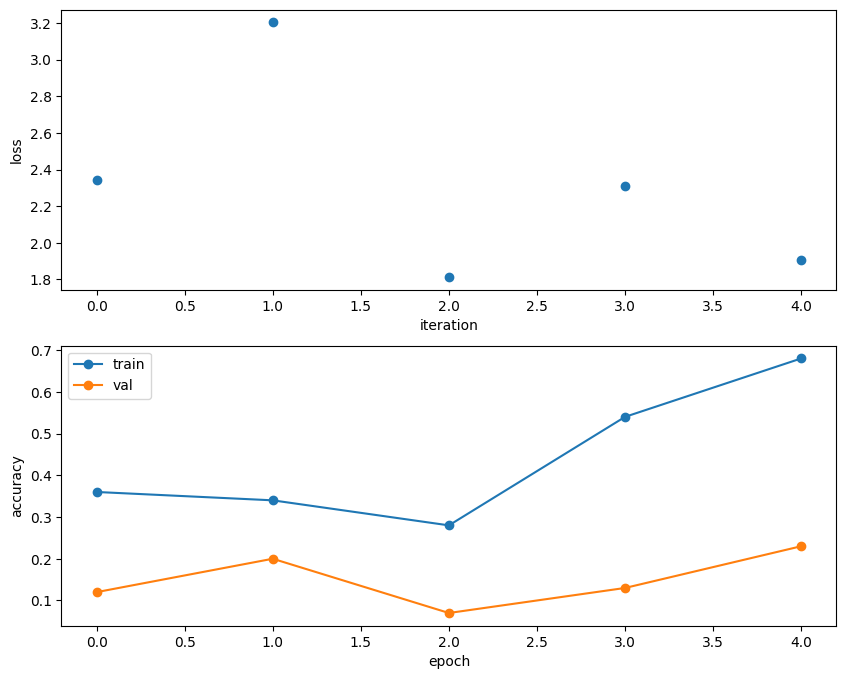

In [56]:
plt.subplot(2, 1, 1)
plt.plot(solver.loss_history, 'o'); plt.xlabel('iteration'); plt.ylabel('loss')
plt.subplot(2, 1, 2)
plt.plot(solver.train_acc_history, '-o')
plt.plot(solver.val_acc_history, '-o')
plt.legend(['train', 'val'], loc='upper left')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.show()


Обучите сеть на полном наборе данных. Выведите accuracy на обучающей и валидационной выборках

In [61]:
model = ThreeLayerConvNet(weight_scale=0.001, hidden_dim=500, reg=0.001)
scores = model.loss(data['X_train_cnn'][:5])
print("Model initialized successfully")
print("Scores shape:", scores.shape)
#data_full_cnn = {
 #   'X_train': data['X_train_cnn'][:500],
  #  'y_train': data['y_train'][:500],
   # 'X_val':   data['X_val_cnn'][:200],
    #'y_val':   data['y_val'][:200],
#}

#model = ThreeLayerConvNet(weight_scale=0.001, hidden_dim=500, reg=0.001)
#solver = Solver(model, data_full_cnn, num_epochs=1, batch_size=50,
 #               update_rule='adam', optim_config={'learning_rate': 1e-3},
  #              verbose=True, print_every=20)
#solver.train()


Model initialized successfully
Scores shape: (5, 10)


In [62]:
print("Full data training accuracy:", solver.check_accuracy(data_full_cnn['X_train'], data_full_cnn['y_train']))


Full data training accuracy: 0.094


In [63]:
print("Full data validation accuracy:", solver.check_accuracy(data_full_cnn['X_val'], data_full_cnn['y_val']))


Full data validation accuracy: 0.065


Визуализируйте фильтры на первом слое обученной сети

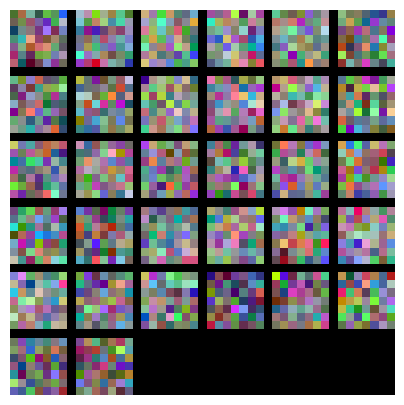

In [64]:
from scripts.vis_utils import visualize_grid

grid = visualize_grid(model.params['W1'].transpose(0, 2, 3, 1))
plt.imshow(grid.astype('uint8'))
plt.axis('off')
plt.gcf().set_size_inches(5, 5)
plt.show()
